# Configuración del Entorno

In [ ]:
# Configuración inicial del entorno
import sys
import warnings
warnings.filterwarnings('ignore')

# Verificar versión de Python
assert sys.version_info >= (3, 7), "Este notebook requiere Python 3.7 o superior"

print(f"✅ Python {sys.version_info.major}.{sys.version_info.minor} instalado correctamente")

✅ Python 3.12 instalado correctamente


In [ ]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_palette("husl")

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [ ]:
# Verificar versiones de librerías críticas
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1"), "Requiere scikit-learn >= 1.0.1"
print(f"✅ scikit-learn {sklearn.__version__} instalado")

✅ scikit-learn 1.6.1 instalado


# Descargar Dataset

[Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

In [ ]:
import tarfile
import zipfile
import urllib.request

def load_students_data():
    data_path = Path("datasets")
    data_path.mkdir(parents=True, exist_ok=True)

    zip_path = data_path / "students_performance.zip"
    extract_dir = data_path / "students_performance"
    csv_path = data_path / "students_performance" / "StudentsPerformance.csv"

    if csv_path.is_file():
        print("📁 Cargando datos desde caché local...")
        return pd.read_csv(csv_path)

    if not zip_path.is_file():
        print("📥 Descargando dataset...")
        url = "https://github.com/Adrephos/machinelearning/raw/refs/heads/master/data/students_performance.zip"
        try:
            urllib.request.urlretrieve(url, zip_path)
            print("✅ Descarga completada")
        except Exception as e:
            print(f"❌ Error en descarga: {e}")
            return None

    print("📦 Extrayendo archivos...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        bad = zf.testzip()
        if bad is not None:
            raise zipfile.BadZipFile(f"Archivo corrupto en el ZIP: {bad}")
        zf.extractall(path=extract_dir)


    print("✅ Datos cargados exitosamente")
    return pd.read_csv(csv_path)

performance = load_students_data()
print(f"\n📊 Dataset cargado: {performance.shape[0]:,} filas × {performance.shape[1]} columnas")

📥 Descargando dataset...
✅ Descarga completada
📦 Extrayendo archivos...
✅ Datos cargados exitosamente

📊 Dataset cargado: 1,000 filas × 8 columnas


# Vista general del Dataset

In [ ]:
# Vista general del dataset
print("=" * 80)
print("INFORMACIÓN GENERAL DEL DATASET".center(80))
print("=" * 80)

display(performance.head())

# Información detallada
print("\n" + "=" * 80)
print("ESTRUCTURA DE DATOS".center(80))
print("=" * 80)
performance.info()

# Estadísticas descriptivas
print("\n" + "=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS".center(80))
print("=" * 80)
display(performance.describe().round(2).T)

                        INFORMACIÓN GENERAL DEL DATASET                         


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75



                              ESTRUCTURA DE DATOS                               
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

                           ESTADÍSTICAS DESCRIPTIVAS                            


,count,mean,std,min,25%,50%,75%,max
math score,1000.00,66.09,15.16,0.00,57.00,66.00,77.00,100.00
reading score,1000.00,69.17,14.60,17.00,59.00,70.00,79.00,100.00
writing score,1000.00,68.05,15.20,10.00,57.75,69.00,79.00,100.00


## Variables demográficas

- gender Sexo del estudiante (male, female). Permite analizar posibles diferencias de desempeño académico entre géneros.
- race/ethnicity Agrupación categórica de origen racial/étnico (group A, B, C, D, E). Puede reflejar diferencias en contexto sociocultural o acceso a recursos educativos.
- parental level of education Nivel educativo de los padres (high school, some college, bachelor’s, master’s, etc.). Sirve como un indicador socioeconómico y cultural relevante en el rendimiento escolar.
## Variables socioeconómicas

- lunch Tipo de almuerzo recibido (standard o free/reduced). Funciona como un proxy de nivel socioeconómico: quienes reciben almuerzo gratuito o reducido suelen pertenecer a familias con menos recursos.
- test preparation course Si el estudiante completó o no un curso de preparación para los exámenes. Relacionado con acceso a recursos adicionales y preparación académica.

## Variables de desempeño académico (numéricas)

- math score Puntaje en matemáticas (0–100). Variable cuantitativa continua.
- reading score Puntaje en lectura (0–100). Permite comparar habilidades de comprensión verbal.
- writing score Puntaje en escritura (0–100). Complementa las habilidades de lenguaje junto con lectura

In [ ]:
# Diccionario de metadatos
metadata = {
    'Variable': [
        'gender',
        'race/ethnicity',
        'parental level of education',
        'lunch',
        'test preparation course',
        'math score',
        'reading score',
        'writing score'
    ],
    'Tipo': [
        'Categórica',
        'Categórica',
        'Categórica',
        'Categórica',
        'Categórica',
        'Numérica',
        'Numérica',
        'Numérica'
    ],
    'Descripción': [
        'Género del estudiante (male/female)',
        'Grupo racial/étnico asignado (A, B, C, D, E)',
        'Nivel educativo de los padres (high school, bachelor, master, etc.)',
        'Tipo de almuerzo recibido (standard o free/reduced)',
        'Participación en curso de preparación de examen (none/completed)',
        'Puntaje obtenido en matemáticas (0–100)',
        'Puntaje obtenido en lectura (0–100)',
        'Puntaje obtenido en escritura (0–100)'
    ],
    'Valores Faltantes': [
        performance['gender'].isnull().sum(),
        performance['race/ethnicity'].isnull().sum(),
        performance['parental level of education'].isnull().sum(),
        performance['lunch'].isnull().sum(),
        performance['test preparation course'].isnull().sum(),
        performance['math score'].isnull().sum(),
        performance['reading score'].isnull().sum(),
        performance['writing score'].isnull().sum()
    ]
}

df_metadata = pd.DataFrame(metadata)
display(df_metadata)

,Variable,Tipo,Descripción,Valores Faltantes
0,gender,Categórica,Género del estudiante (male/female),0
1,race/ethnicity,Categórica,"Grupo racial/étnico asignado (A, B, C, D, E)",0
2,parental level of education,Categórica,"Nivel educativo de los padres (high school, ba...",0
3,lunch,Categórica,Tipo de almuerzo recibido (standard o free/red...,0
4,test preparation course,Categórica,Participación en curso de preparación de exame...,0
5,math score,Numérica,Puntaje obtenido en matemáticas (0–100),0
6,reading score,Numérica,Puntaje obtenido en lectura (0–100),0
7,writing score,Numérica,Puntaje obtenido en escritura (0–100),0


In [ ]:
def analyze_missing_values(df):
    """Análisis completo de valores faltantes"""
    missing_df = pd.DataFrame({
        'Columna': df.columns,
        'Valores_Faltantes': df.isnull().sum(),
        'Porcentaje': (df.isnull().sum() / len(df)) * 100,
        'Tipo_Dato': df.dtypes
    })

    missing_df = missing_df[missing_df['Valores_Faltantes'] > 0].sort_values(
        'Porcentaje', ascending=False
    )

    if len(missing_df) > 0:
        # Visualización
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # Gráfico de barras
        ax1.bar(missing_df['Columna'], missing_df['Porcentaje'], color='coral')
        ax1.set_xlabel('Columna')
        ax1.set_ylabel('Porcentaje de Valores Faltantes (%)')
        ax1.set_title('Valores Faltantes por Columna')
        ax1.axhline(y=5, color='r', linestyle='--', label='Umbral 5%')
        ax1.legend()

        # Heatmap de patrones
        import seaborn as sns
        msno_data = df[missing_df['Columna'].tolist()].isnull().astype(int)
        sns.heatmap(msno_data.corr(), annot=True, fmt='.2f', cmap='coolwarm',
                   ax=ax2, vmin=-1, vmax=1)
        ax2.set_title('Correlación de Patrones de Valores Faltantes')

        plt.tight_layout()
        plt.show()

        return missing_df
    else:
        print("✅ No hay valores faltantes en el dataset")
        return None

missing_analysis = analyze_missing_values(performance)
if missing_analysis is not None:
    display(missing_analysis)

✅ No hay valores faltantes en el dataset


## Estadísticas descriptivas: Los números cuentan historias

### 1. Media vs. Mediana
- **Math score** → media = 66.09, mediana = 66.00 → distribución simétrica, no hay sesgo importante.  
- **Reading score** → media = 69.17, mediana = 70.00 → media < mediana → ligero sesgo a la izquierda (más valores bajos que altos).  
- **Writing score** → media = 68.05, mediana = 69.00 → media < mediana → también sesgo a la izquierda, aunque leve.  

En general, las distribuciones de puntajes son bastante equilibradas, con apenas un sesgo hacia los valores bajos en lectura y escritura.

---

### 2. Desviación estándar
- Math: 15.16  
- Reading: 14.60  
- Writing: 15.20  

La desviación es relativamente similar en las tres áreas (~15 puntos).  
Esto significa que hay variabilidad considerable en los puntajes: algunos estudiantes se desempeñan muy mal (<40) mientras otros obtienen puntajes perfectos (100).

---

### 3. Min/Max sospechosos
- Mínimos: math = 0, reading = 17, writing = 10.  
  - El 0 en matemáticas podría ser un caso extremo (estudiante ausente o fallo en el examen).  
- Máximos: todos llegan a 100.  
  - Sugiere que el examen tenía un puntaje máximo fijo (no hay censura, simplemente es el límite natural del test).  

---

### 4. Rango intercuartílico (IQR)
- En todos los casos, el 50% central de los estudiantes está entre aproximadamente 57 y 79 puntos.  
- Esto muestra que la mayoría tiene rendimiento medio, con extremos que generan la variabilidad.

---

### Conclusión general
El dataset refleja un grupo de estudiantes con desempeño bastante equilibrado entre lectura, escritura y matemáticas.  
Sin embargo, la dispersión alta indica grandes desigualdades: hay estudiantes con puntajes muy bajos junto a otros con puntajes perfectos.  
La ligera asimetría hacia puntajes bajos en lectura y escritura podría relacionarse con factores socioeconómicos o de preparación.


# Analisis Univariado
## Variables Númericas

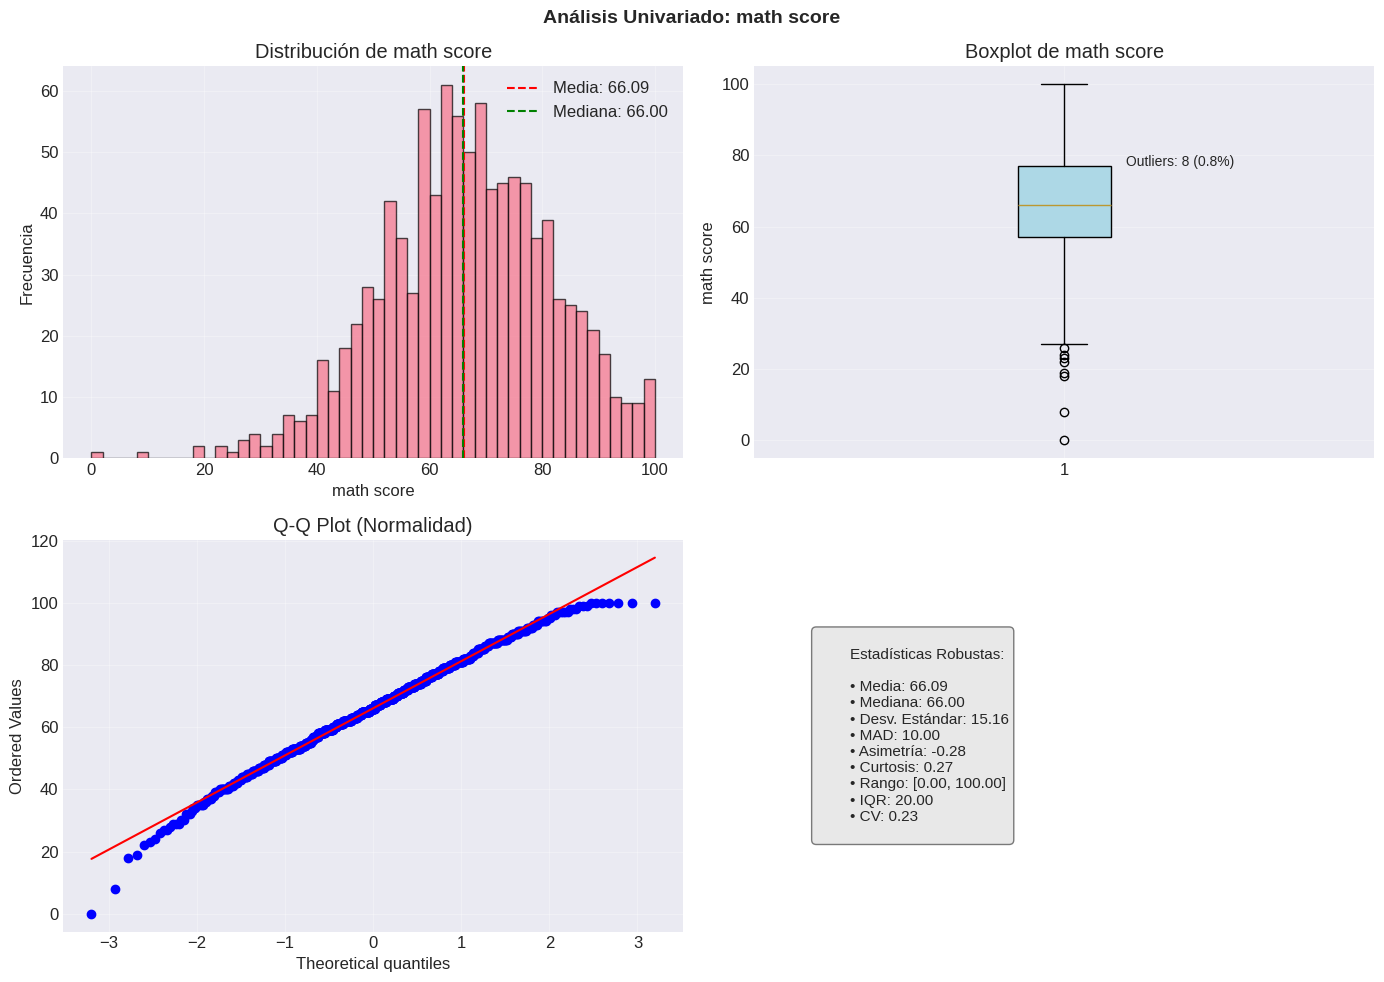

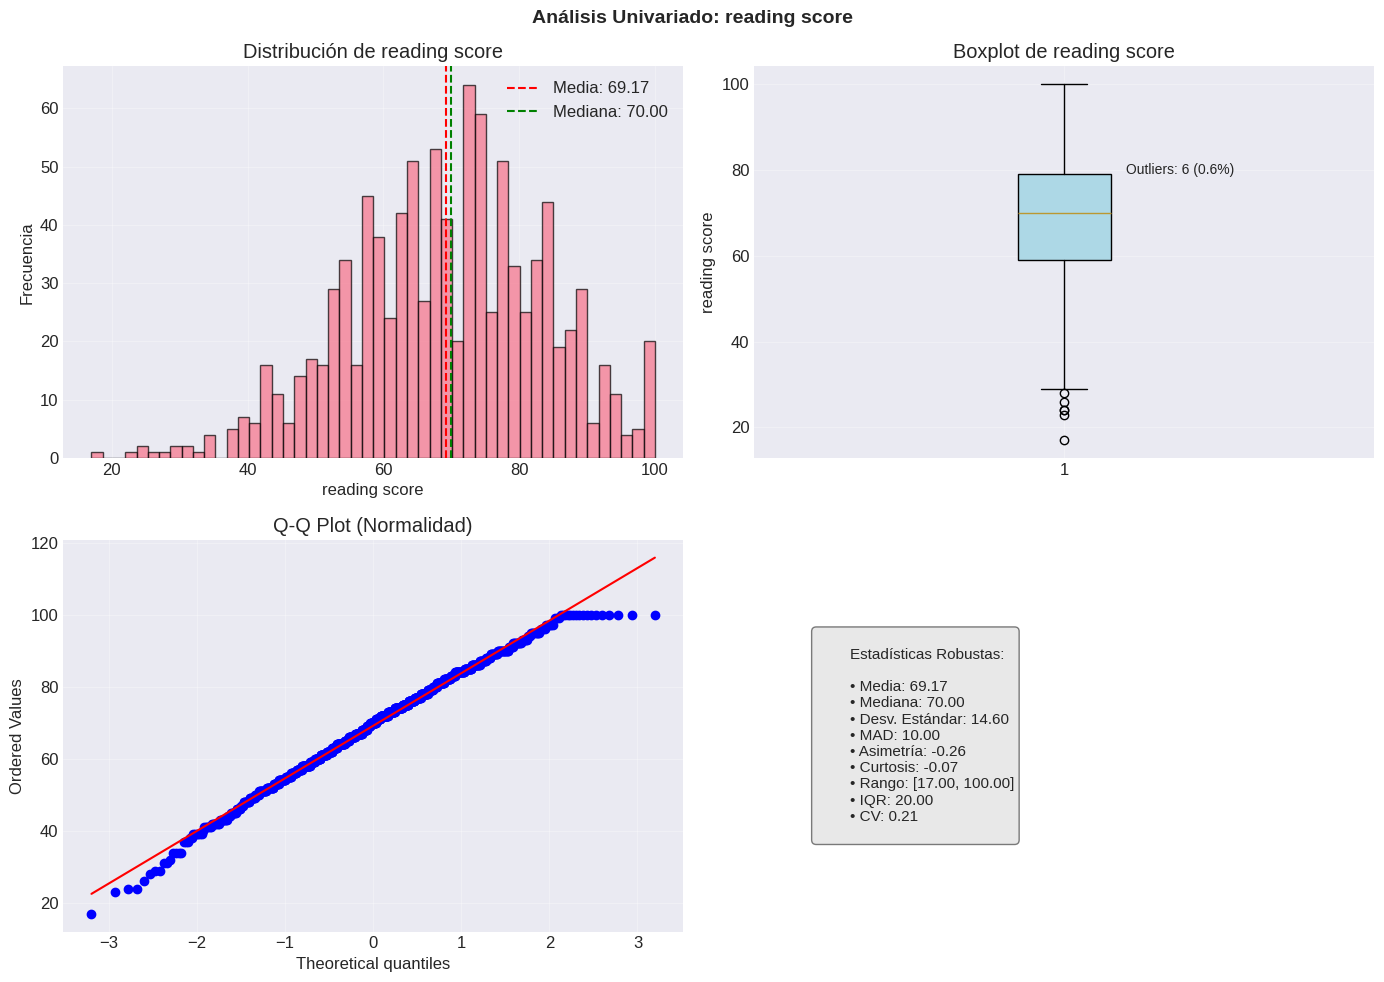

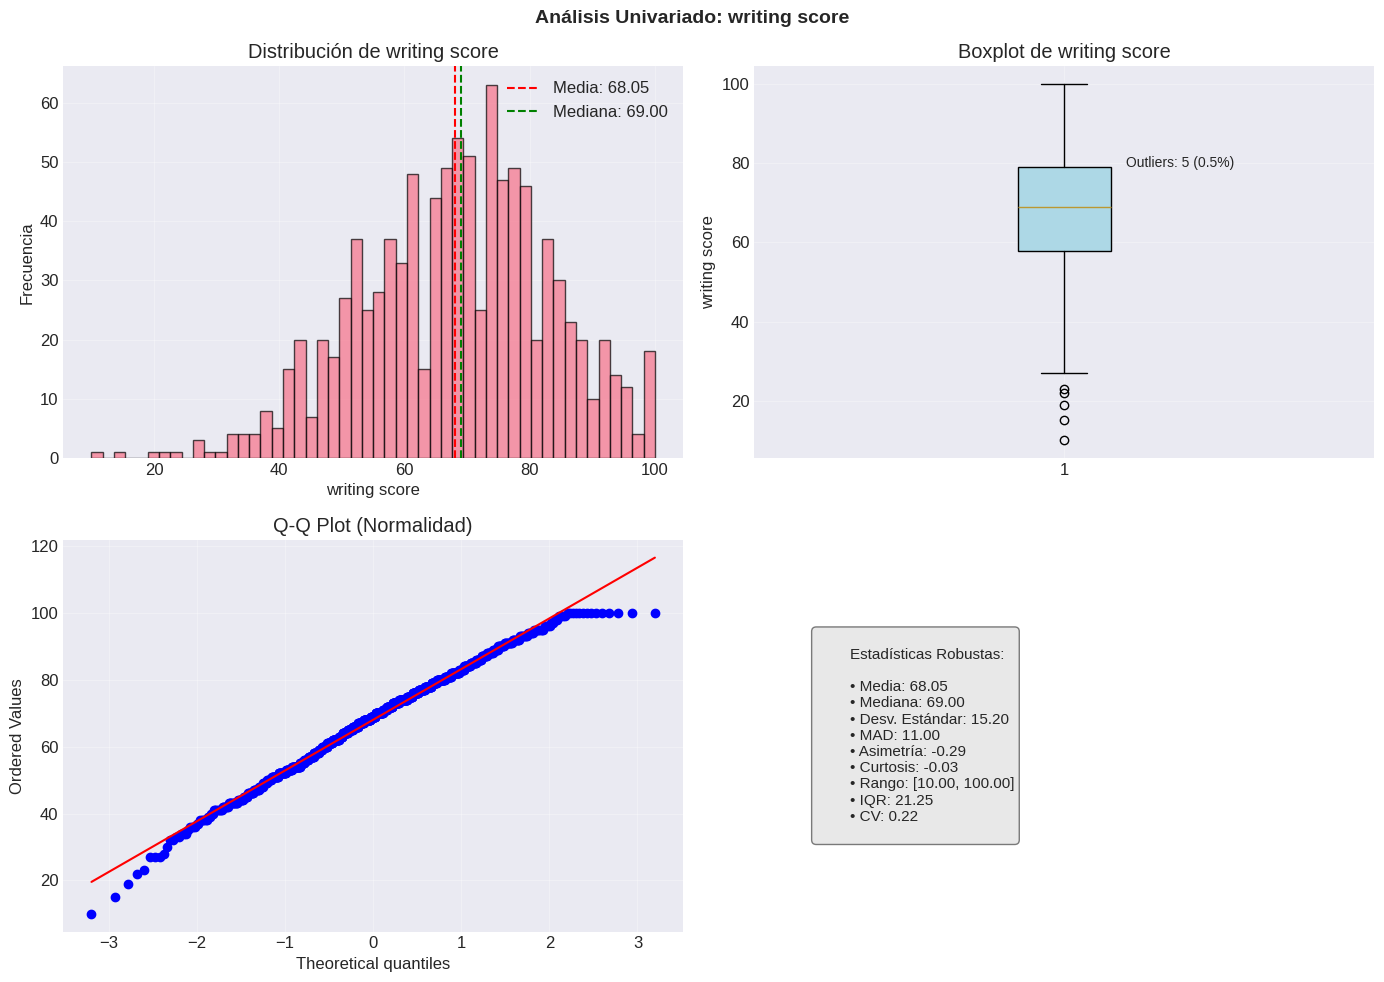

In [ ]:
# Función para análisis univariado robusto
def univariate_analysis(df, column, target=None):
    """Análisis univariado con estadísticas robustas"""

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Histograma con KDE
    ax1 = axes[0, 0]
    df[column].hist(bins=50, edgecolor='black', alpha=0.7, ax=ax1)
    ax1.axvline(df[column].mean(), color='red', linestyle='--', label=f'Media: {df[column].mean():.2f}')
    ax1.axvline(df[column].median(), color='green', linestyle='--', label=f'Mediana: {df[column].median():.2f}')
    ax1.set_title(f'Distribución de {column}')
    ax1.set_xlabel(column)
    ax1.set_ylabel('Frecuencia')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # 2. Boxplot
    ax2 = axes[0, 1]
    bp = ax2.boxplot(df[column].dropna(), vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    ax2.set_title(f'Boxplot de {column}')
    ax2.set_ylabel(column)
    ax2.grid(alpha=0.3)

    # Detectar outliers
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[column] < Q1 - 1.5 * IQR) | (df[column] > Q3 + 1.5 * IQR)]
    ax2.text(1.1, Q3, f'Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)',
             fontsize=10)

    # 3. Q-Q Plot
    ax3 = axes[1, 0]
    from scipy import stats
    stats.probplot(df[column].dropna(), dist="norm", plot=ax3)
    ax3.set_title('Q-Q Plot (Normalidad)')
    ax3.grid(alpha=0.3)

    # 4. Relación con target (si existe)
    ax4 = axes[1, 1]
    if target is not None and target in df.columns:
        ax4.scatter(df[column], df[target], alpha=0.5, s=10)
        ax4.set_xlabel(column)
        ax4.set_ylabel(target)
        ax4.set_title(f'{column} vs {target}')

        # Agregar línea de tendencia
        z = np.polyfit(df[column].dropna(), df[target][df[column].notna()], 1)
        p = np.poly1d(z)
        ax4.plot(df[column].sort_values(), p(df[column].sort_values()),
                "r--", alpha=0.8, label=f'Tendencia')

        # Calcular correlación
        corr = df[column].corr(df[target])
        ax4.text(0.05, 0.95, f'Correlación: {corr:.3f}',
                transform=ax4.transAxes, fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat'))
        ax4.legend()
    else:
        # Estadísticas adicionales
        ax4.axis('off')
        stats_text = f"""
        Estadísticas Robustas:

        • Media: {df[column].mean():.2f}
        • Mediana: {df[column].median():.2f}
        • Desv. Estándar: {df[column].std():.2f}
        • MAD: {stats.median_abs_deviation(df[column].dropna()):.2f}
        • Asimetría: {df[column].skew():.2f}
        • Curtosis: {df[column].kurtosis():.2f}
        • Rango: [{df[column].min():.2f}, {df[column].max():.2f}]
        • IQR: {IQR:.2f}
        • CV: {df[column].std()/df[column].mean():.2f}
        """
        ax4.text(0.1, 0.5, stats_text, transform=ax4.transAxes,
                fontsize=11, verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

    ax4.grid(alpha=0.3)

    plt.suptitle(f'Análisis Univariado: {column}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Analizar variables numéricas clave
for col in ['math score', 'reading score', 'writing score']:
    univariate_analysis(performance, col)

## Variables Categóricas

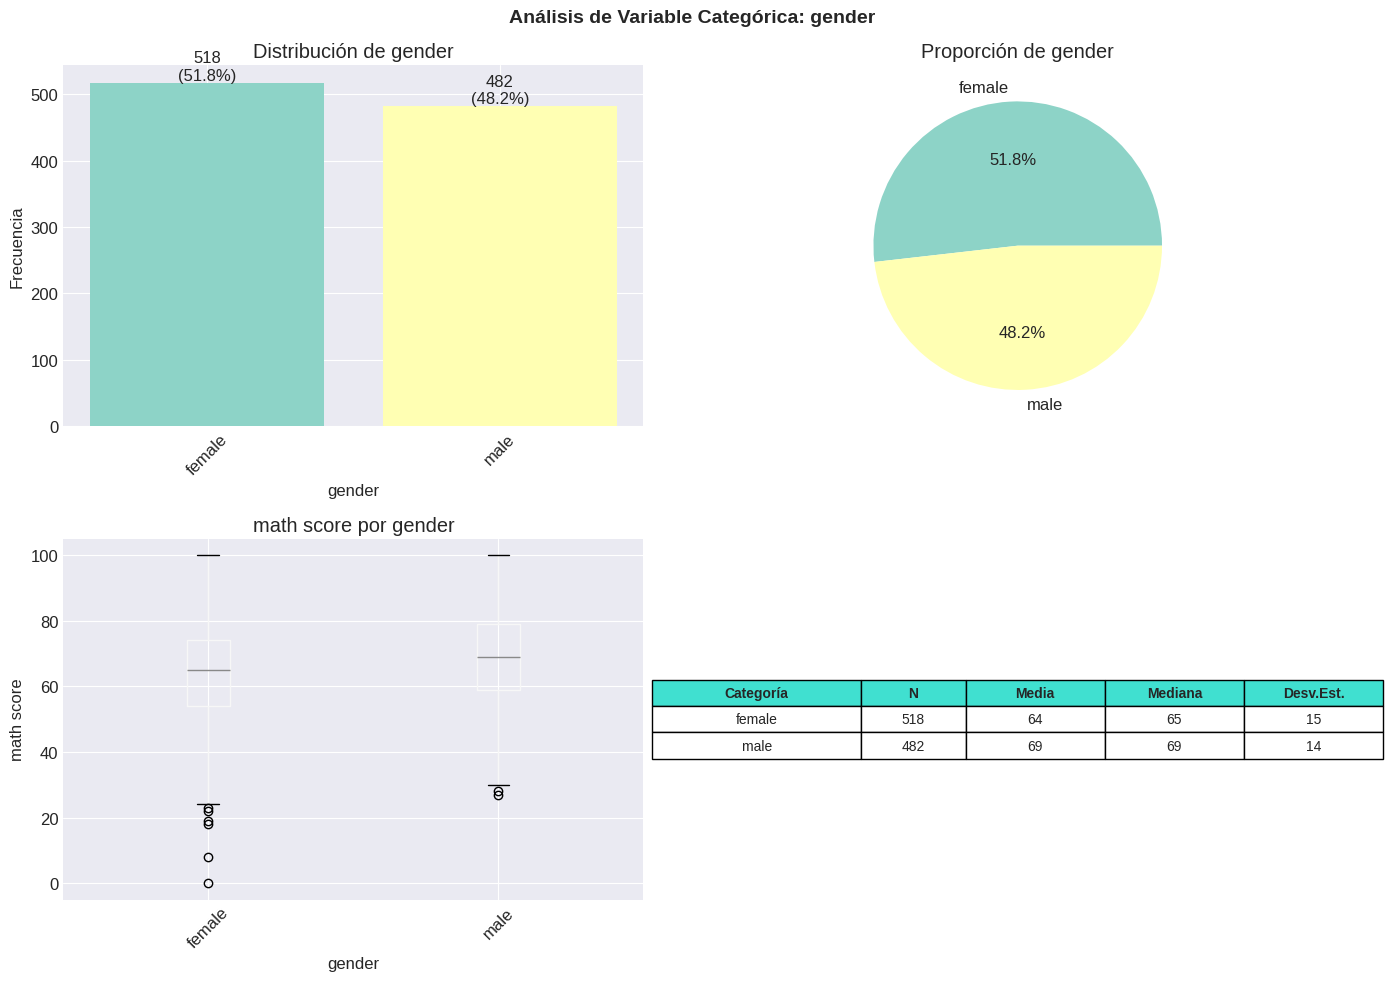

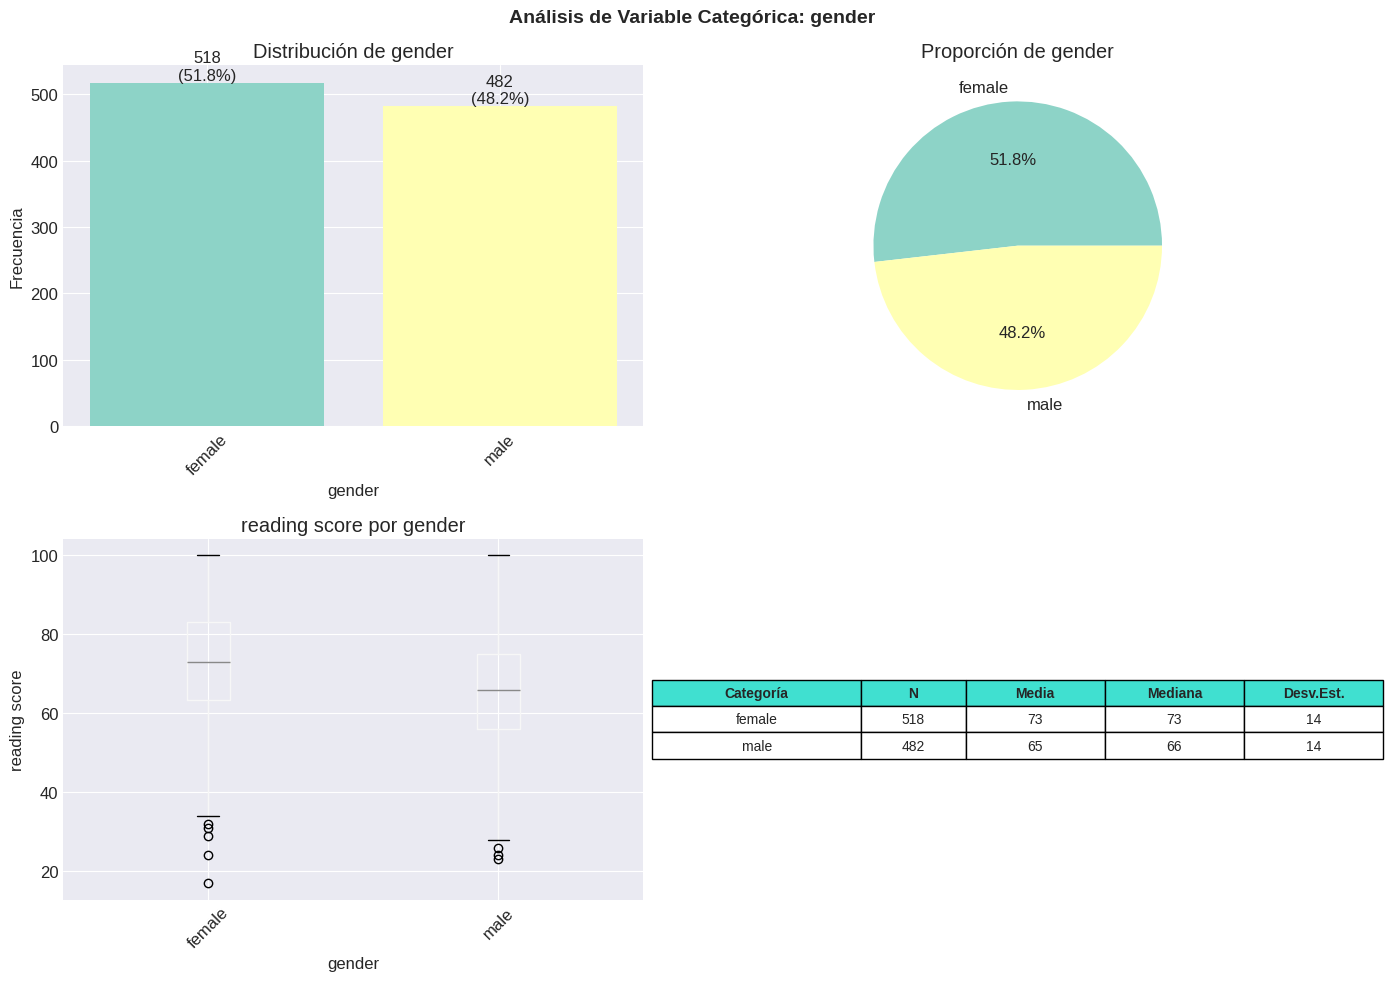

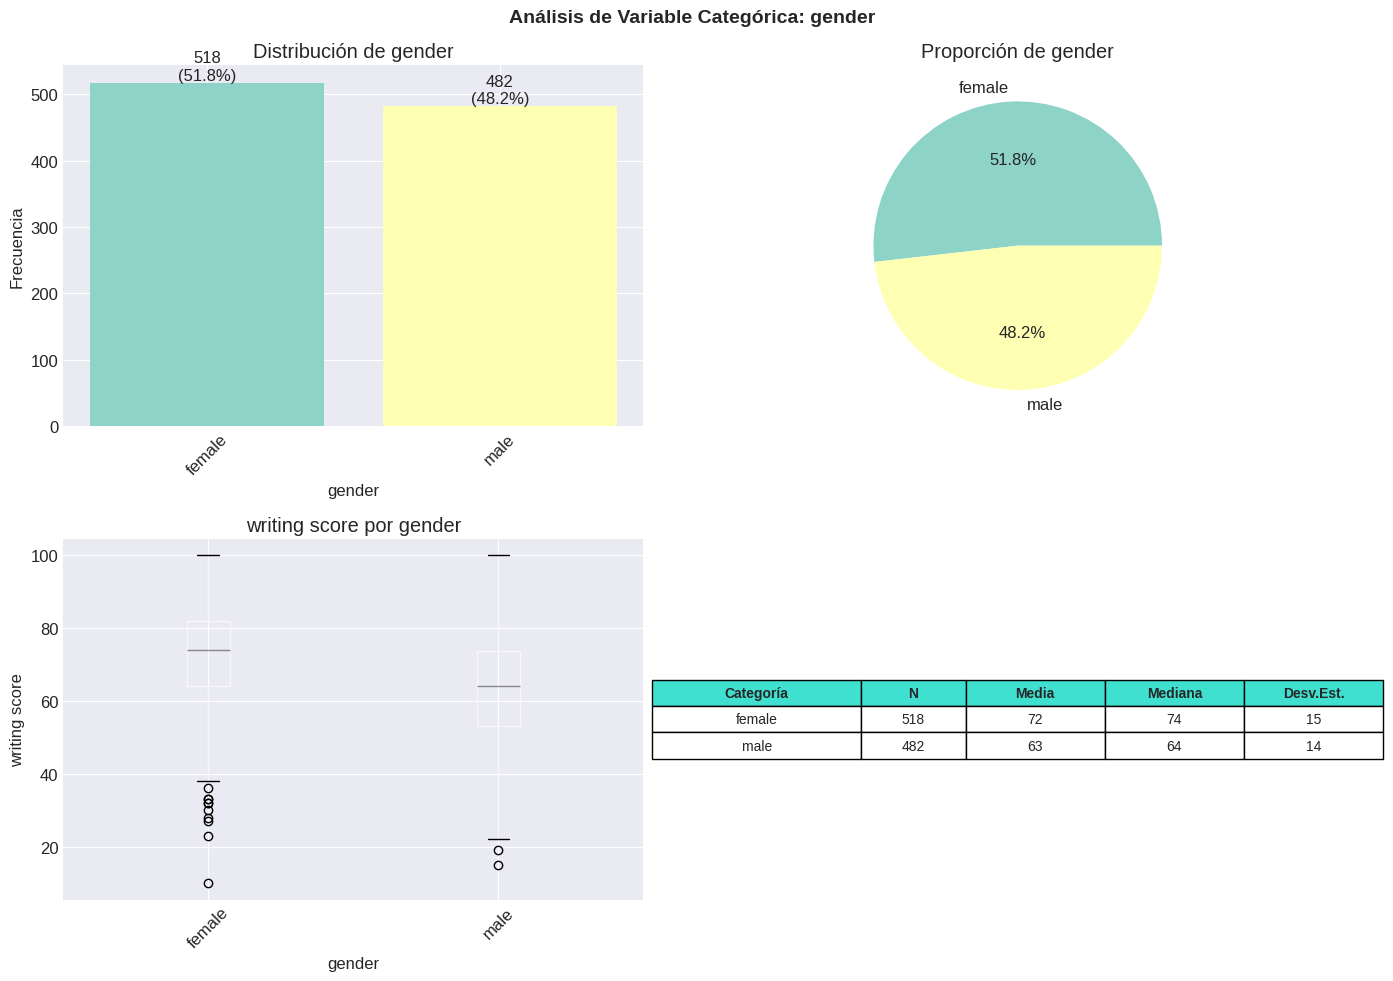

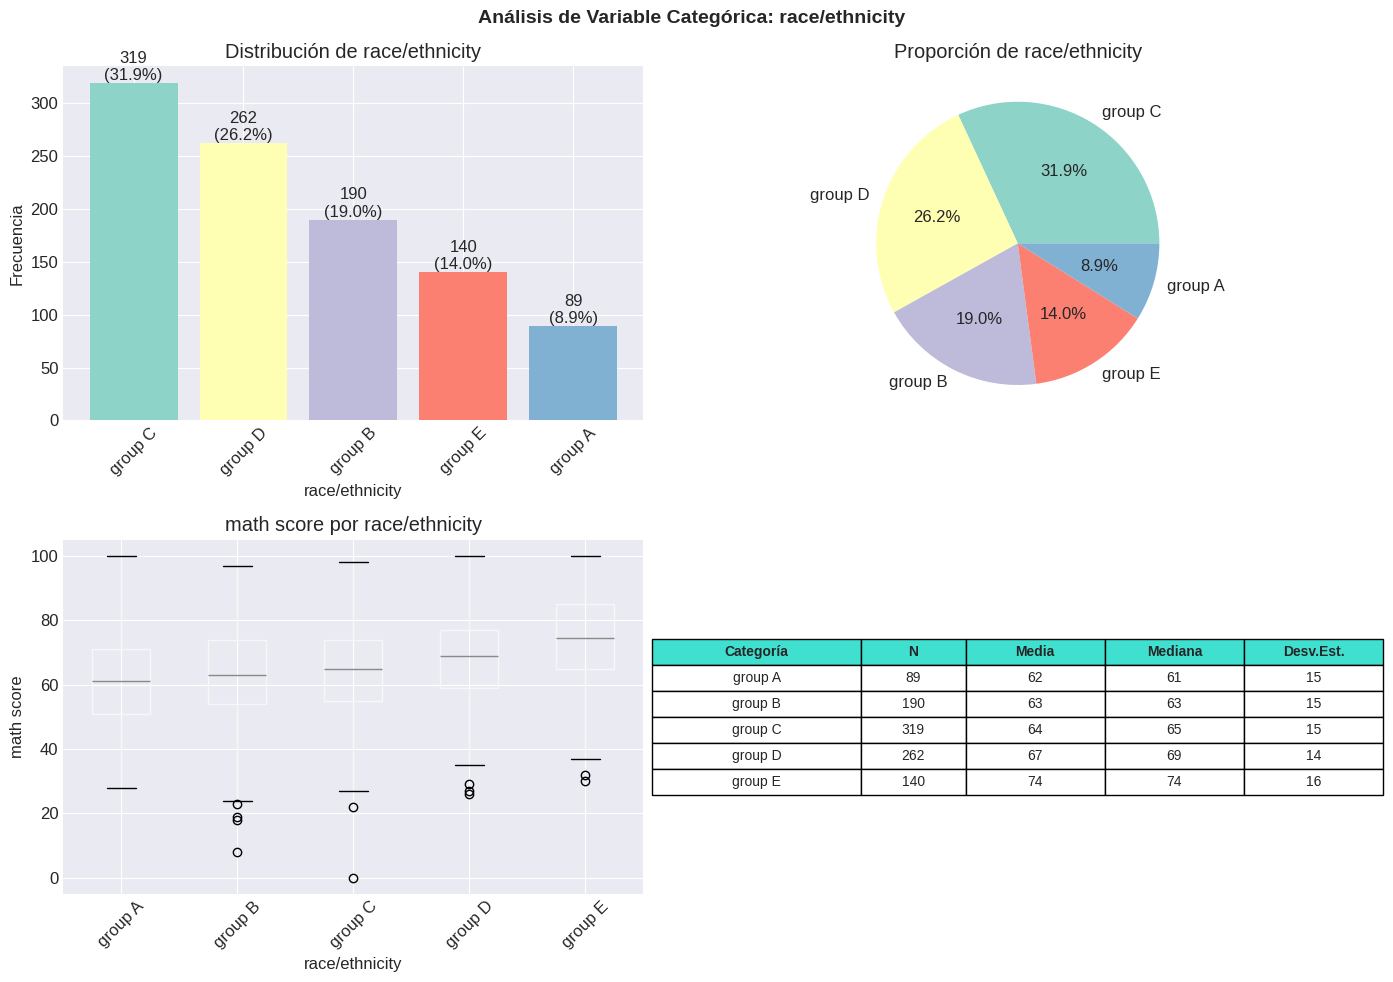

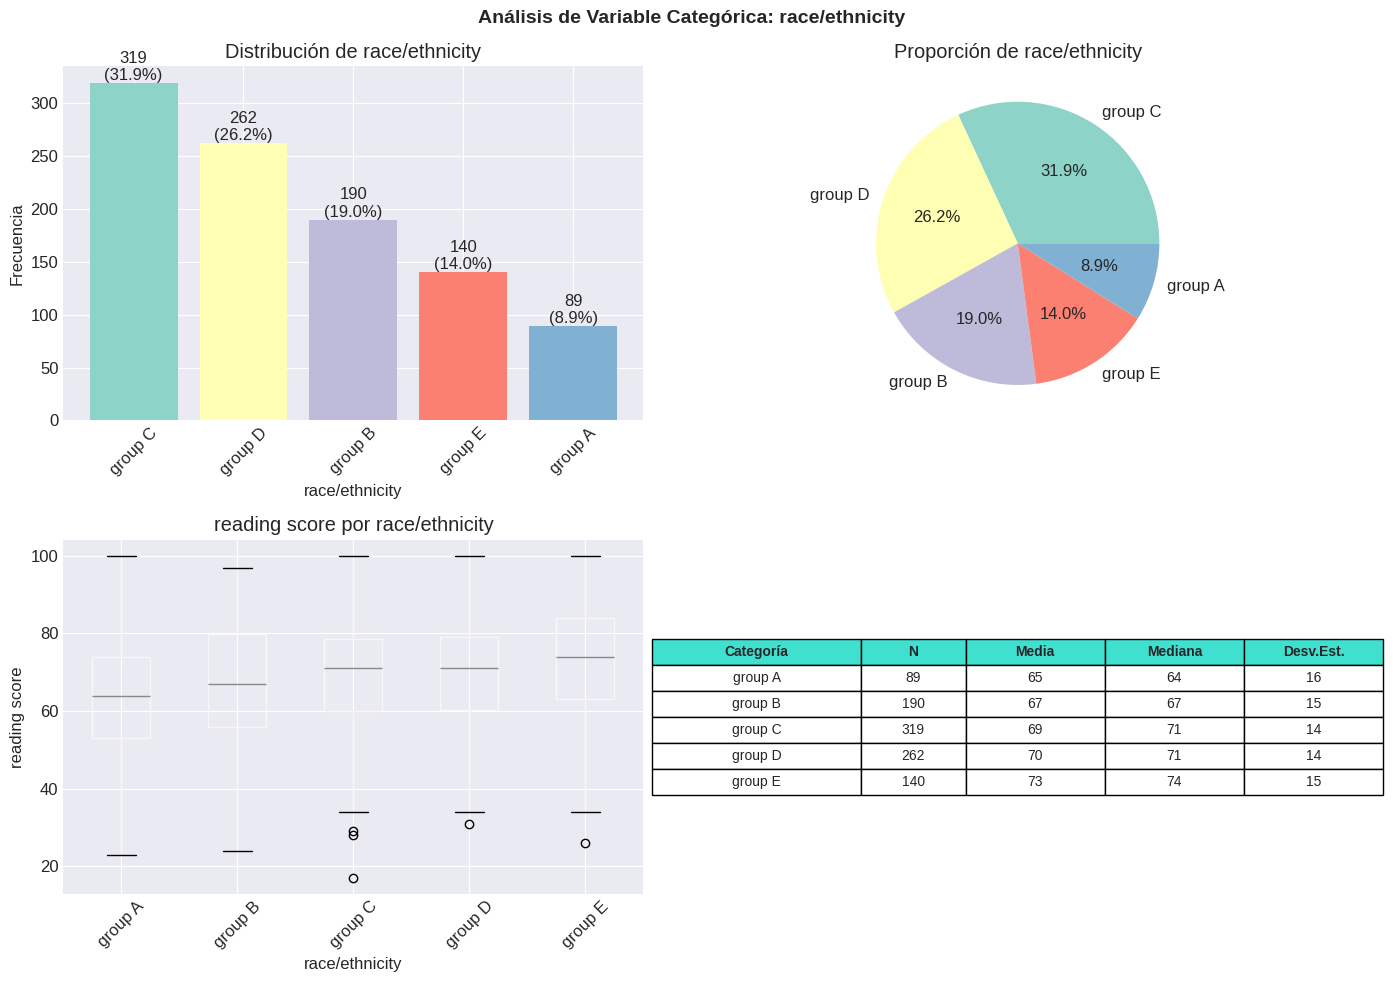

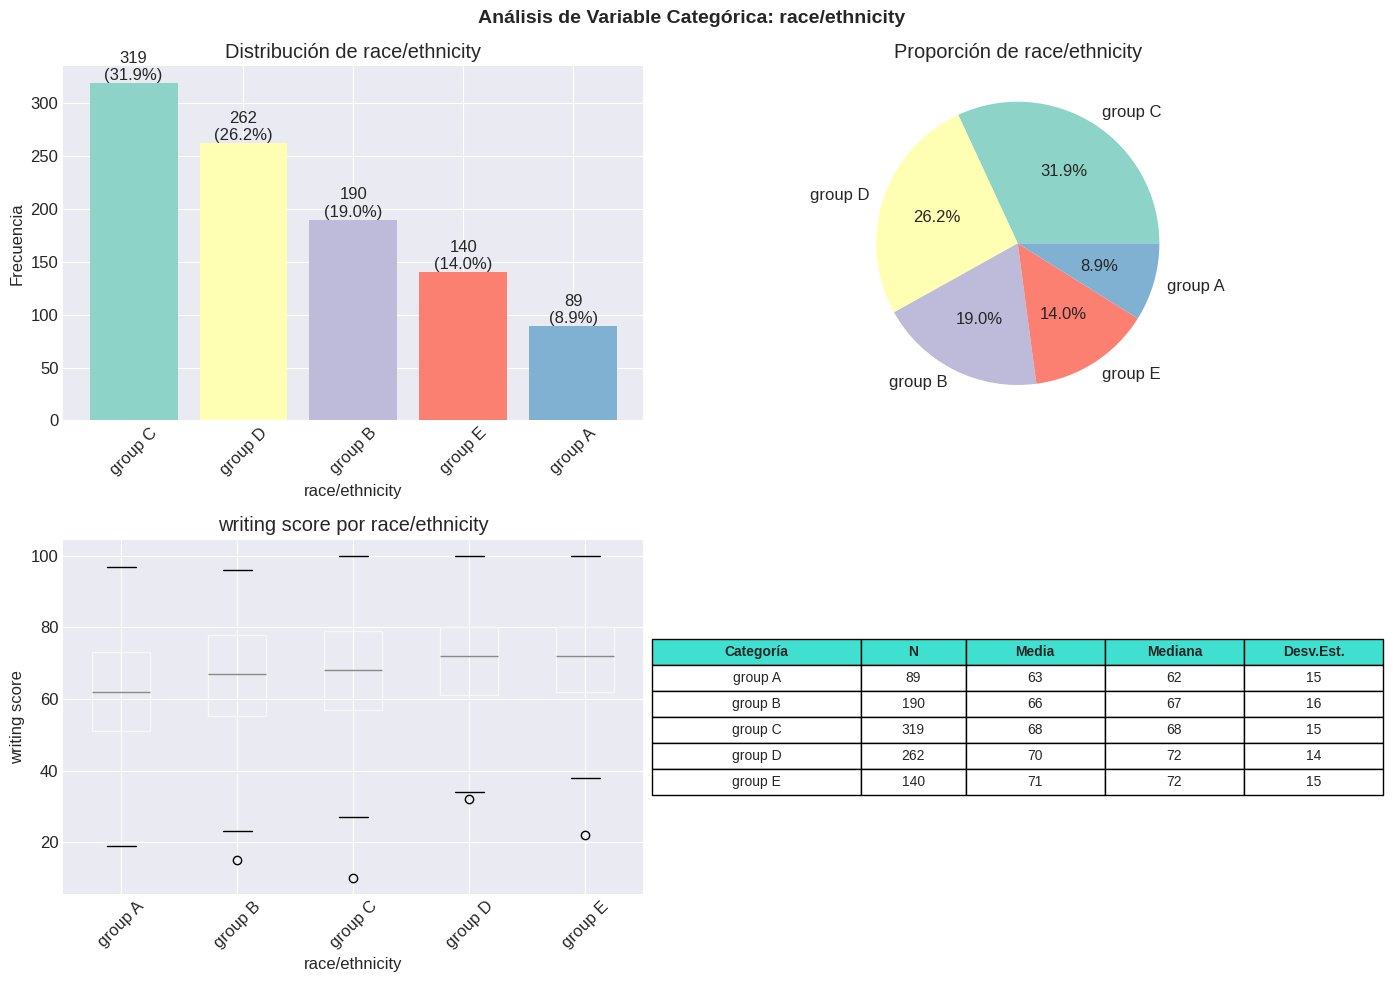

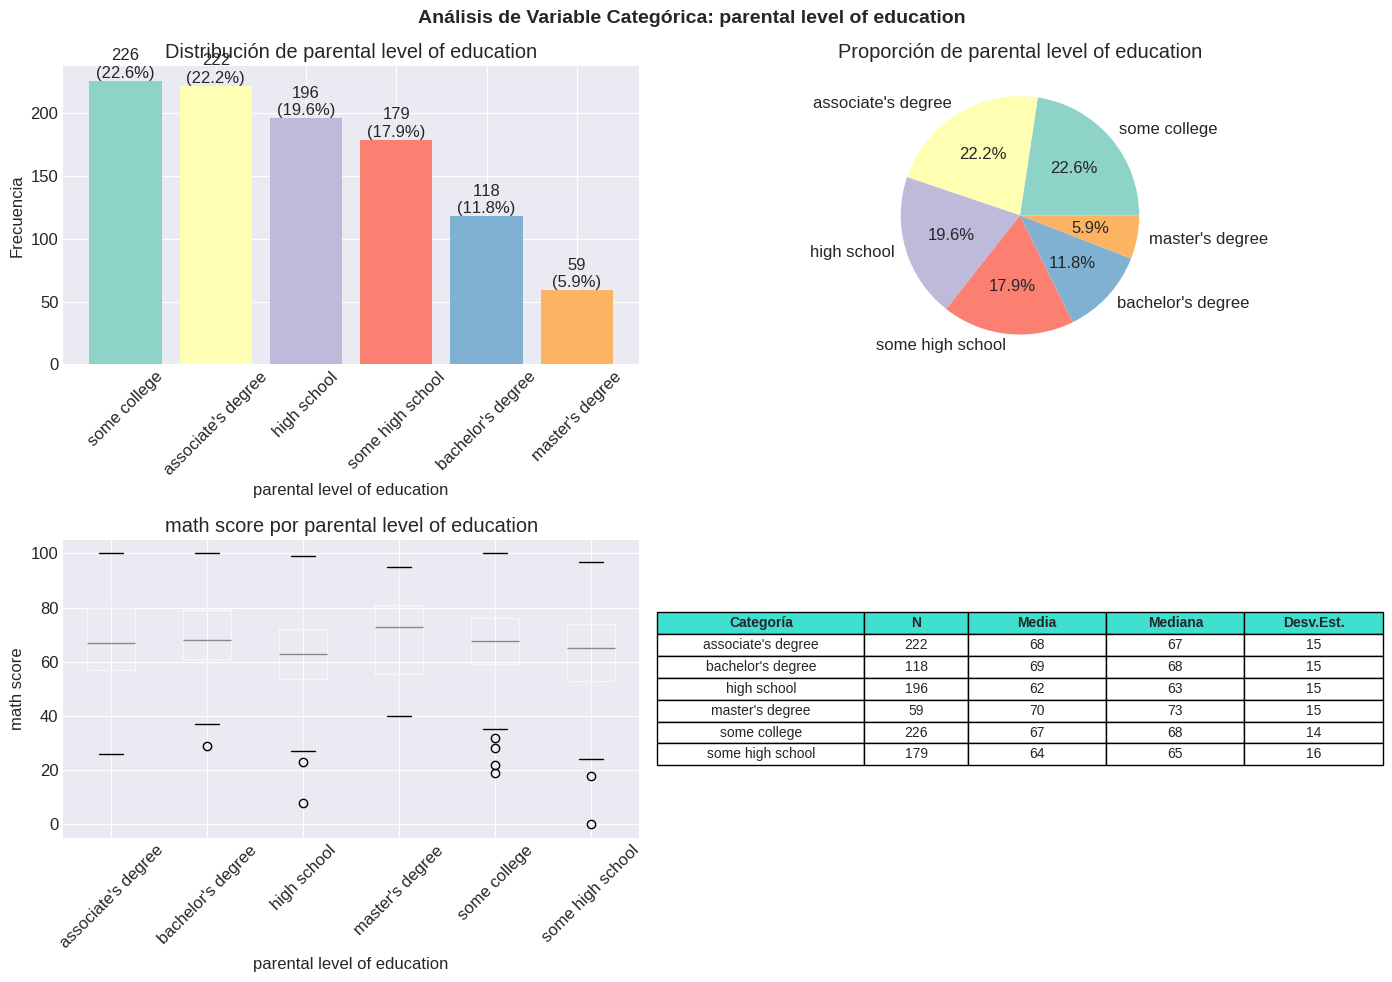

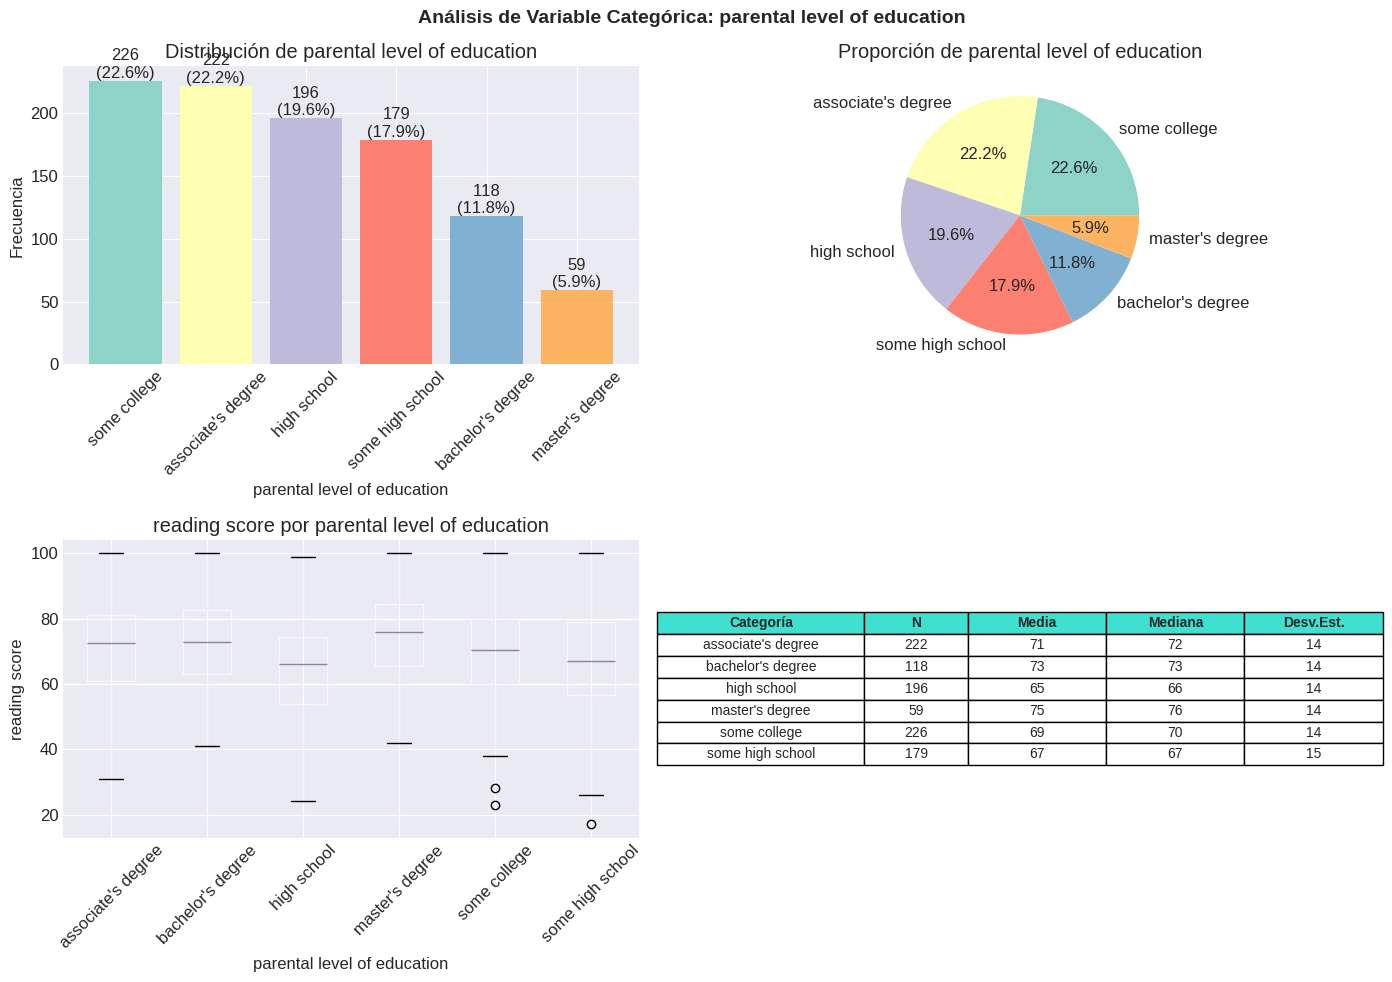

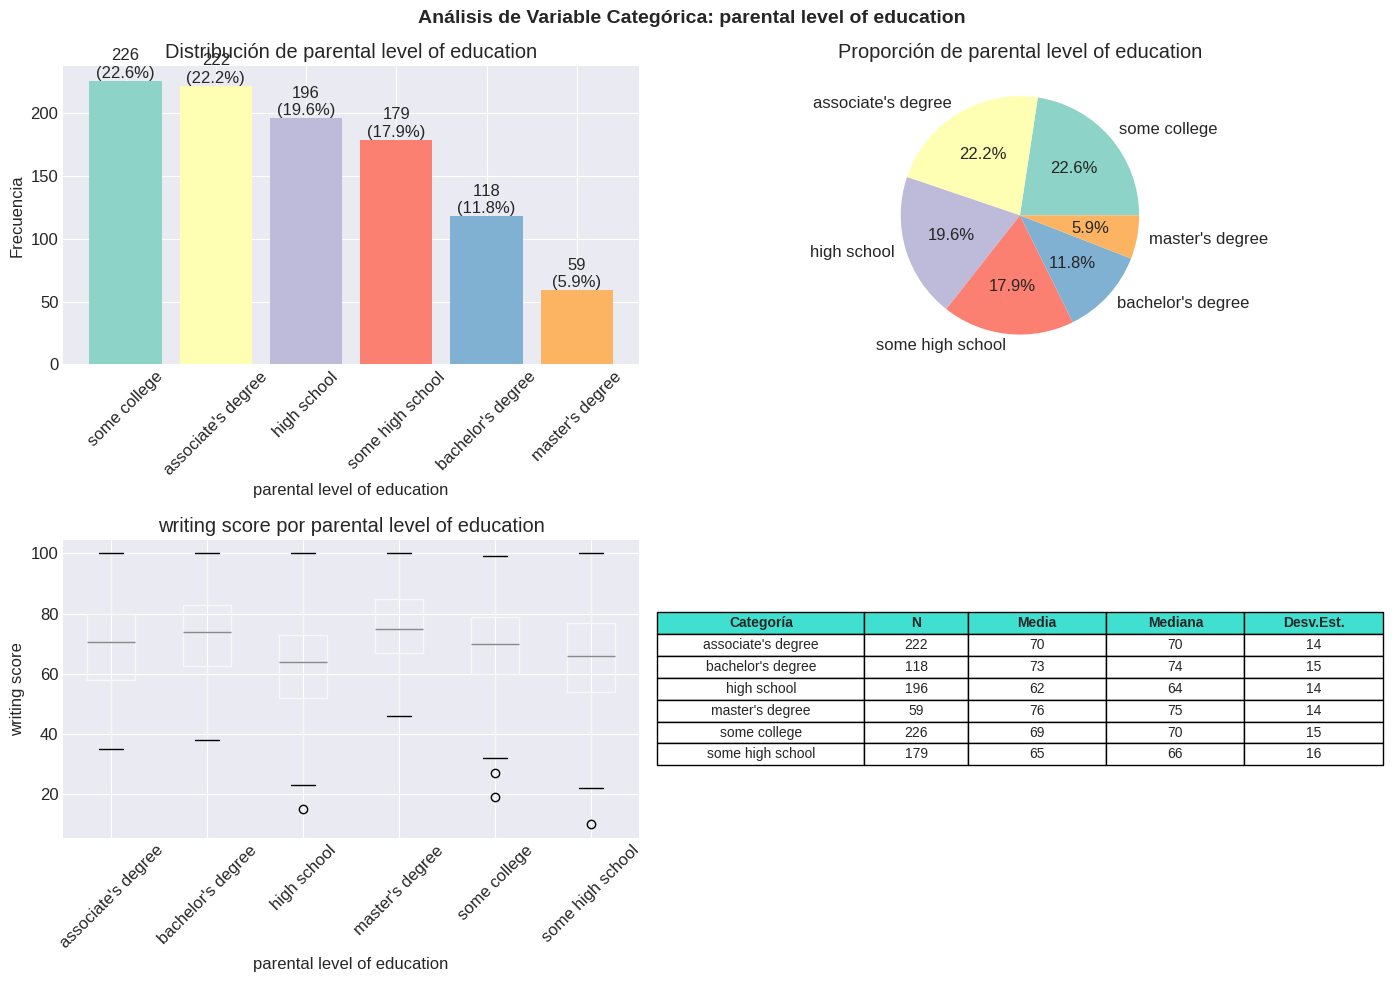

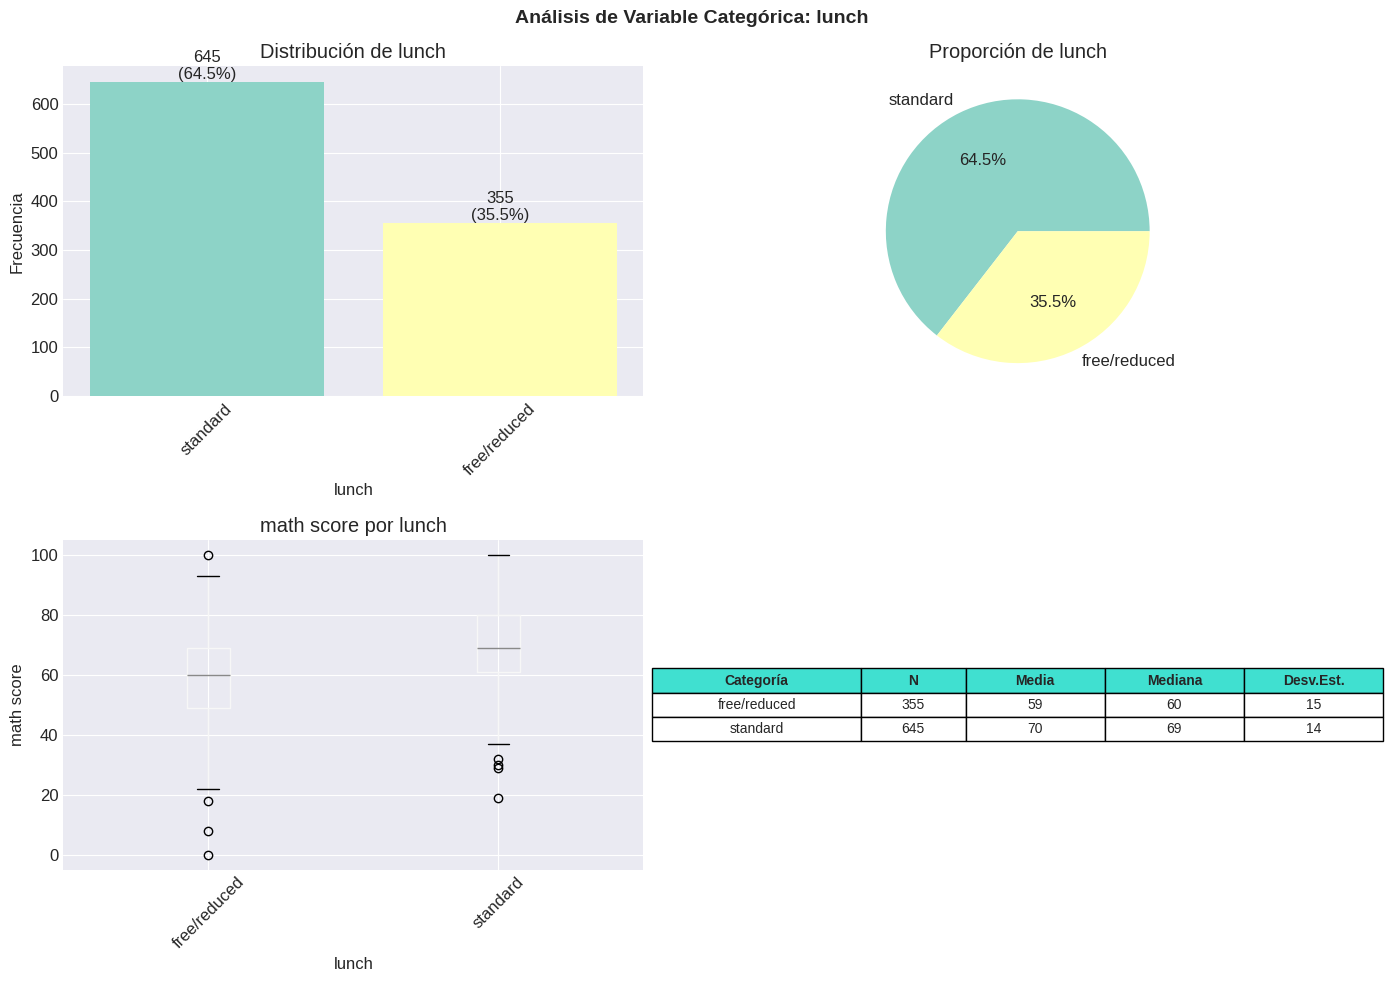

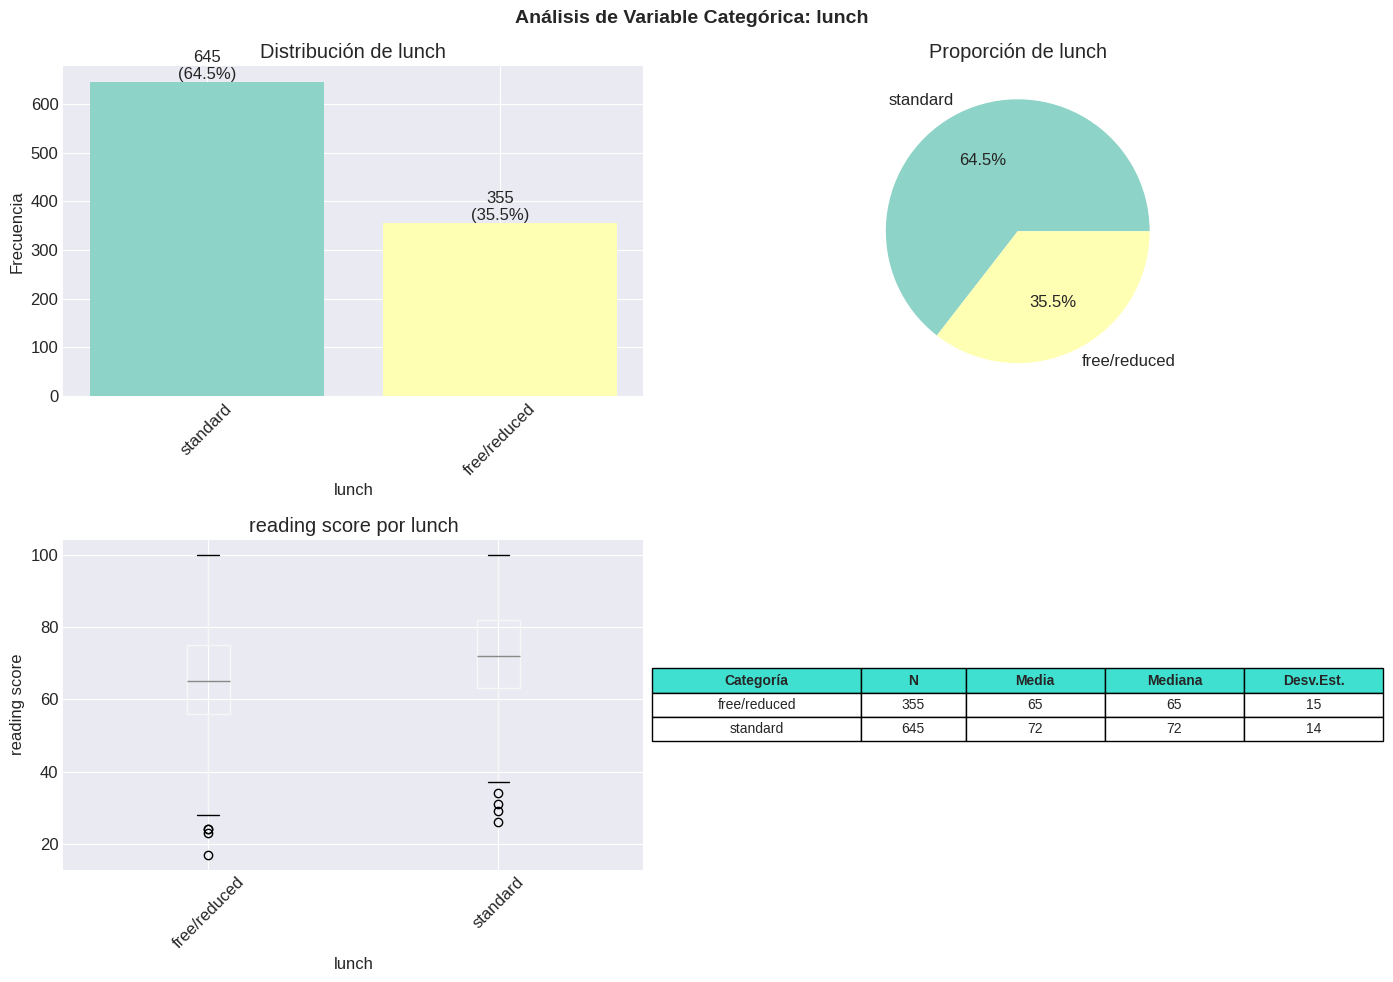

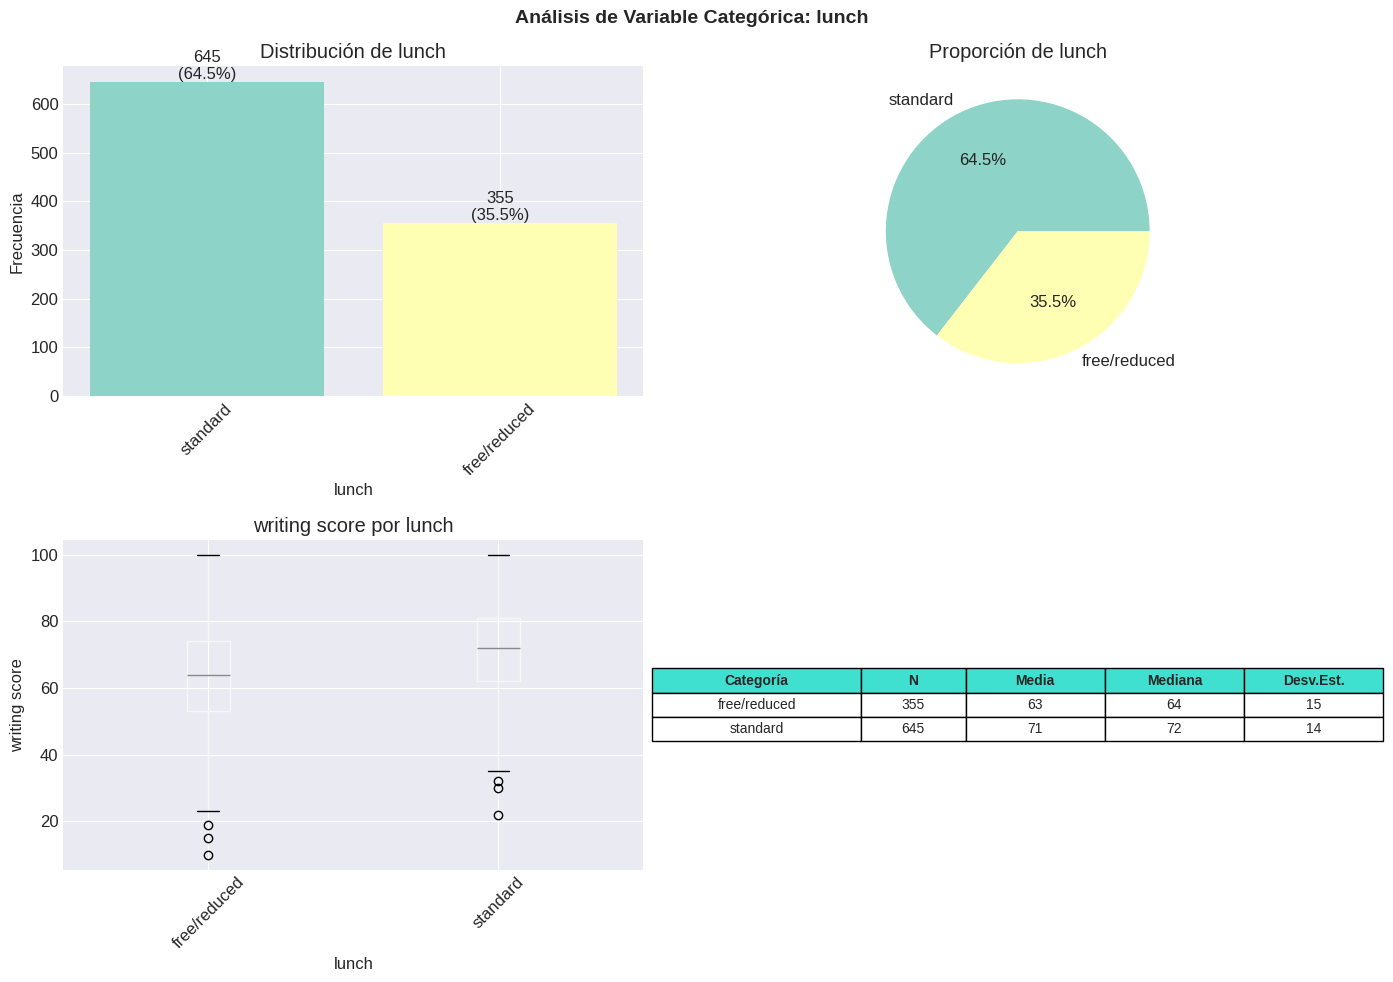

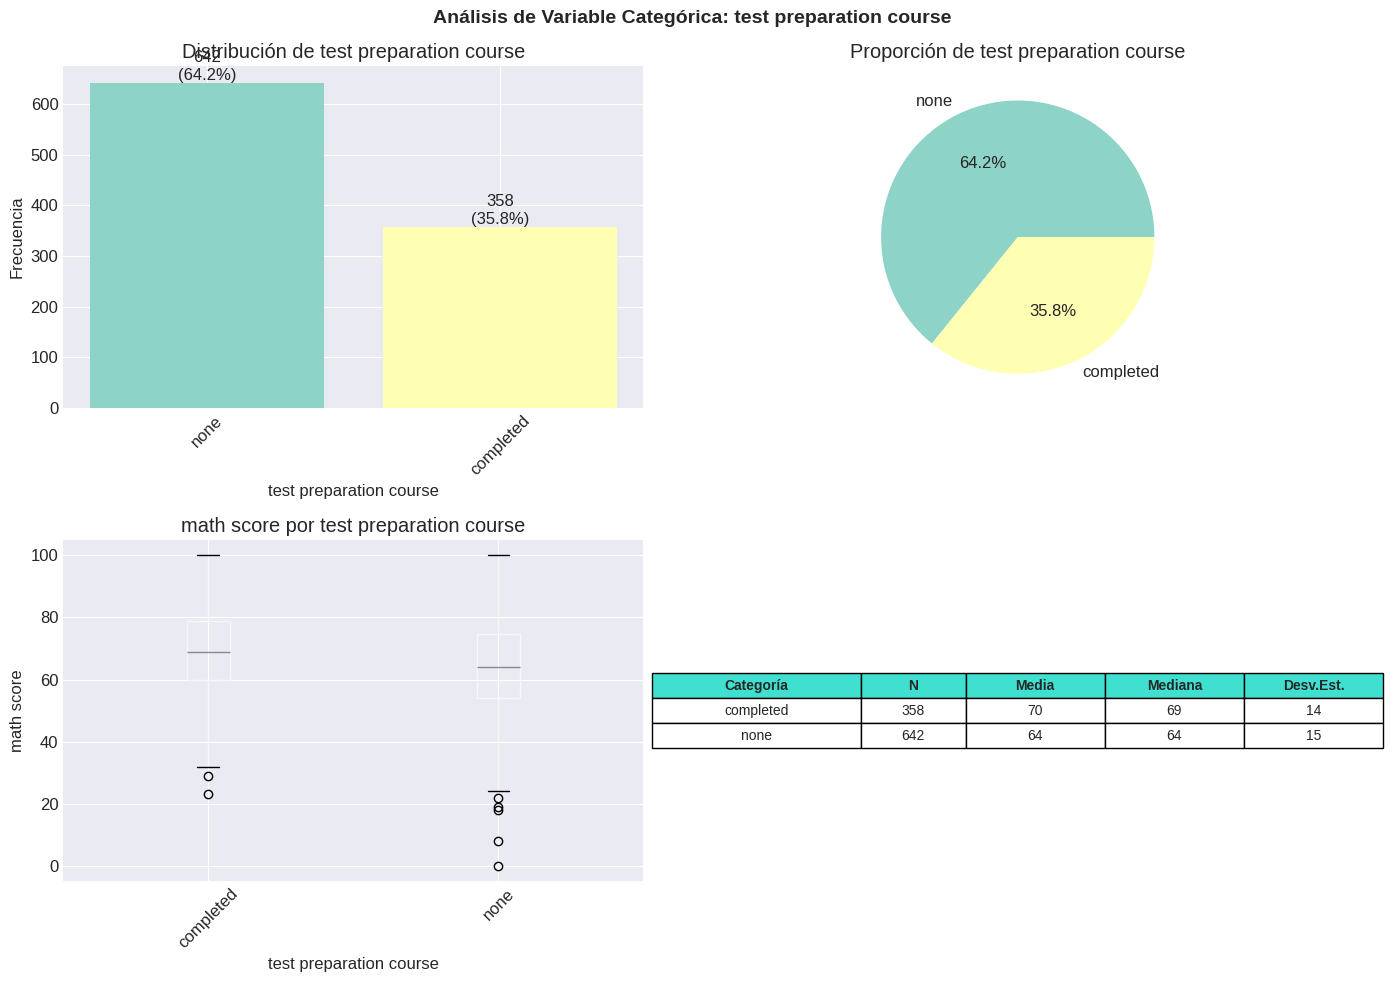

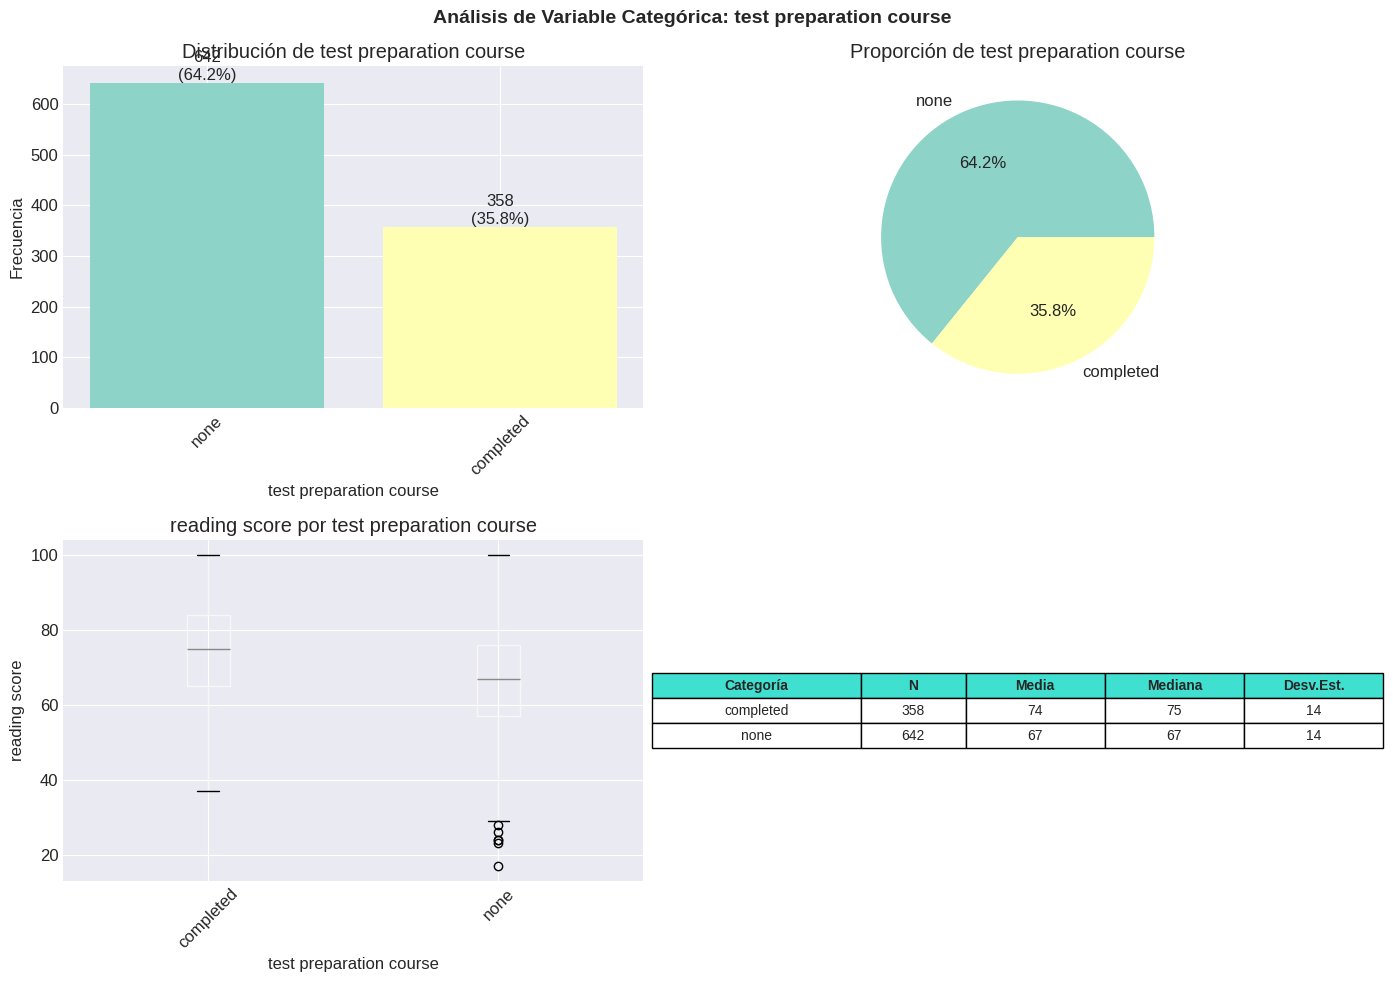

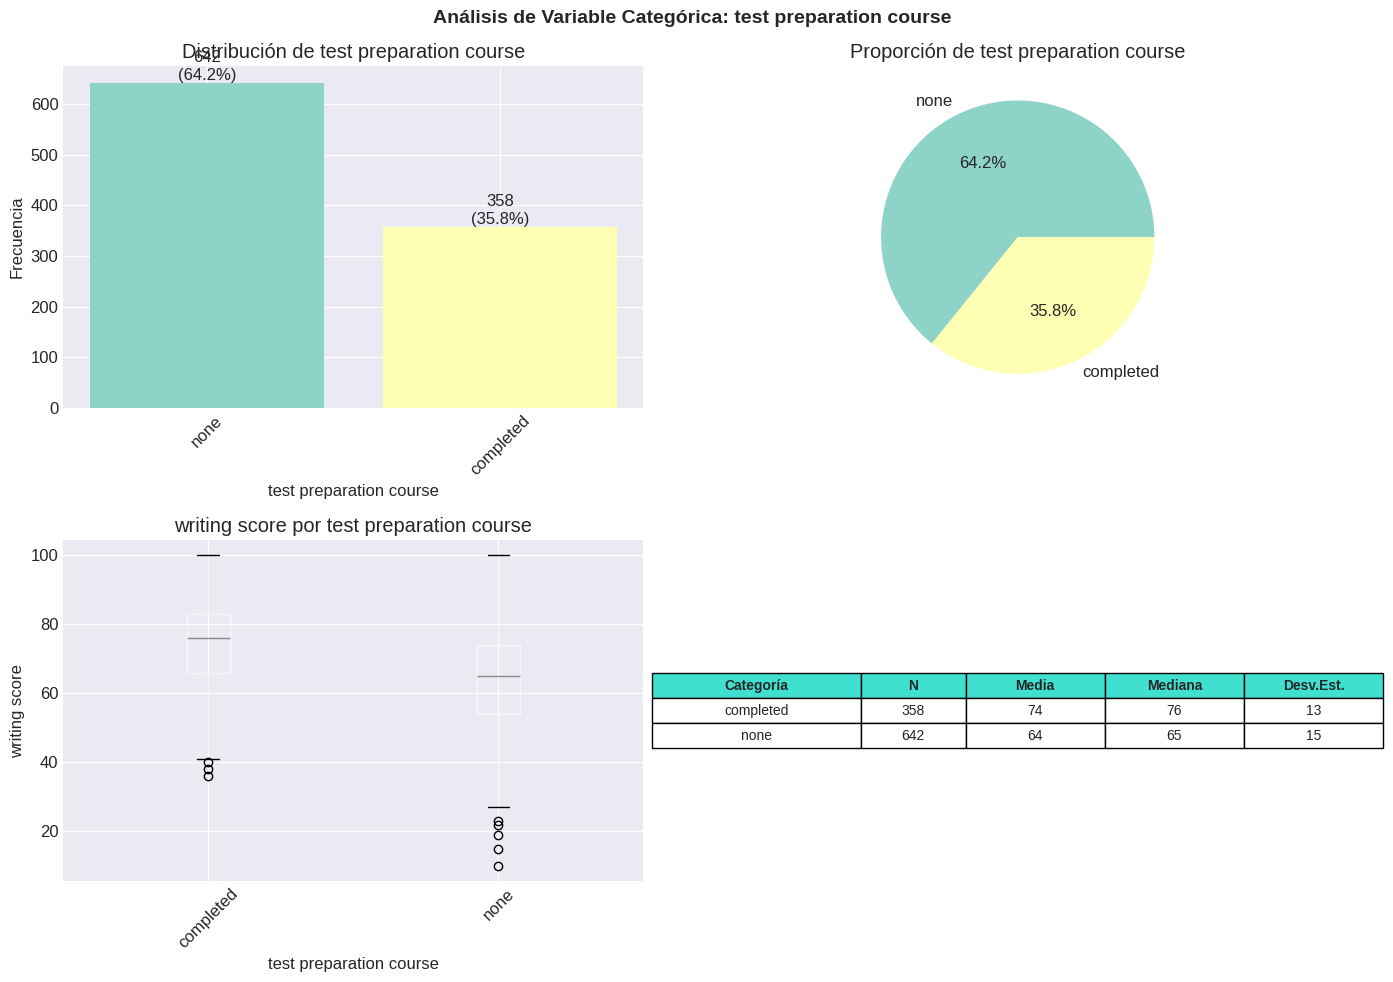

In [ ]:
# Análisis de ocean_proximity
def analyze_categorical(df, cat_col, target_col):
    """Análisis completo de variable categórica"""

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Distribución de categorías
    ax1 = axes[0, 0]
    counts = df[cat_col].value_counts()
    ax1.bar(counts.index, counts.values, color=plt.cm.Set3(range(len(counts))))
    ax1.set_title(f'Distribución de {cat_col}')
    ax1.set_xlabel(cat_col)
    ax1.set_ylabel('Frecuencia')
    ax1.tick_params(axis='x', rotation=45)

    # Agregar porcentajes
    for i, (idx, val) in enumerate(counts.items()):
        ax1.text(i, val, f'{val}\n({val/len(df)*100:.1f}%)',
                ha='center', va='bottom')

    # 2. Pie chart
    ax2 = axes[0, 1]
    ax2.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=plt.cm.Set3(range(len(counts))))
    ax2.set_title(f'Proporción de {cat_col}')

    # 3. Boxplot por categoría
    ax3 = axes[1, 0]
    df.boxplot(column=target_col, by=cat_col, ax=ax3)
    ax3.set_title(f'{target_col} por {cat_col}')
    ax3.set_xlabel(cat_col)
    ax3.set_ylabel(target_col)
    plt.sca(ax3)
    plt.xticks(rotation=45)

    # 4. Estadísticas por categoría
    ax4 = axes[1, 1]
    ax4.axis('off')

    stats_by_cat = df.groupby(cat_col)[target_col].agg([
        'count', 'mean', 'median', 'std'
    ]).round(2)

    table_data = []
    for idx, row in stats_by_cat.iterrows():
        table_data.append([idx, f"{row['count']:.0f}",
                          f"{row['mean']:,.0f}",
                          f"{row['median']:,.0f}",
                          f"{row['std']:,.0f}"])

    table = ax4.table(cellText=table_data,
                     colLabels=['Categoría', 'N', 'Media', 'Mediana', 'Desv.Est.'],
                     cellLoc='center',
                     loc='center',
                     colWidths=[0.3, 0.15, 0.2, 0.2, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)

    # Colorear encabezados
    for i in range(5):
        table[(0, i)].set_facecolor('#40E0D0')
        table[(0, i)].set_text_props(weight='bold')

    plt.suptitle(f'Análisis de Variable Categórica: {cat_col}',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

categorical_cols = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]

target_cols = ['math score', 'reading score', 'writing score']

for cat in categorical_cols:
    for target in target_cols:
        analyze_categorical(performance, cat, target)


# Matriz de Correlación


>>> Análisis de correlación usando 'math score' como variable objetivo



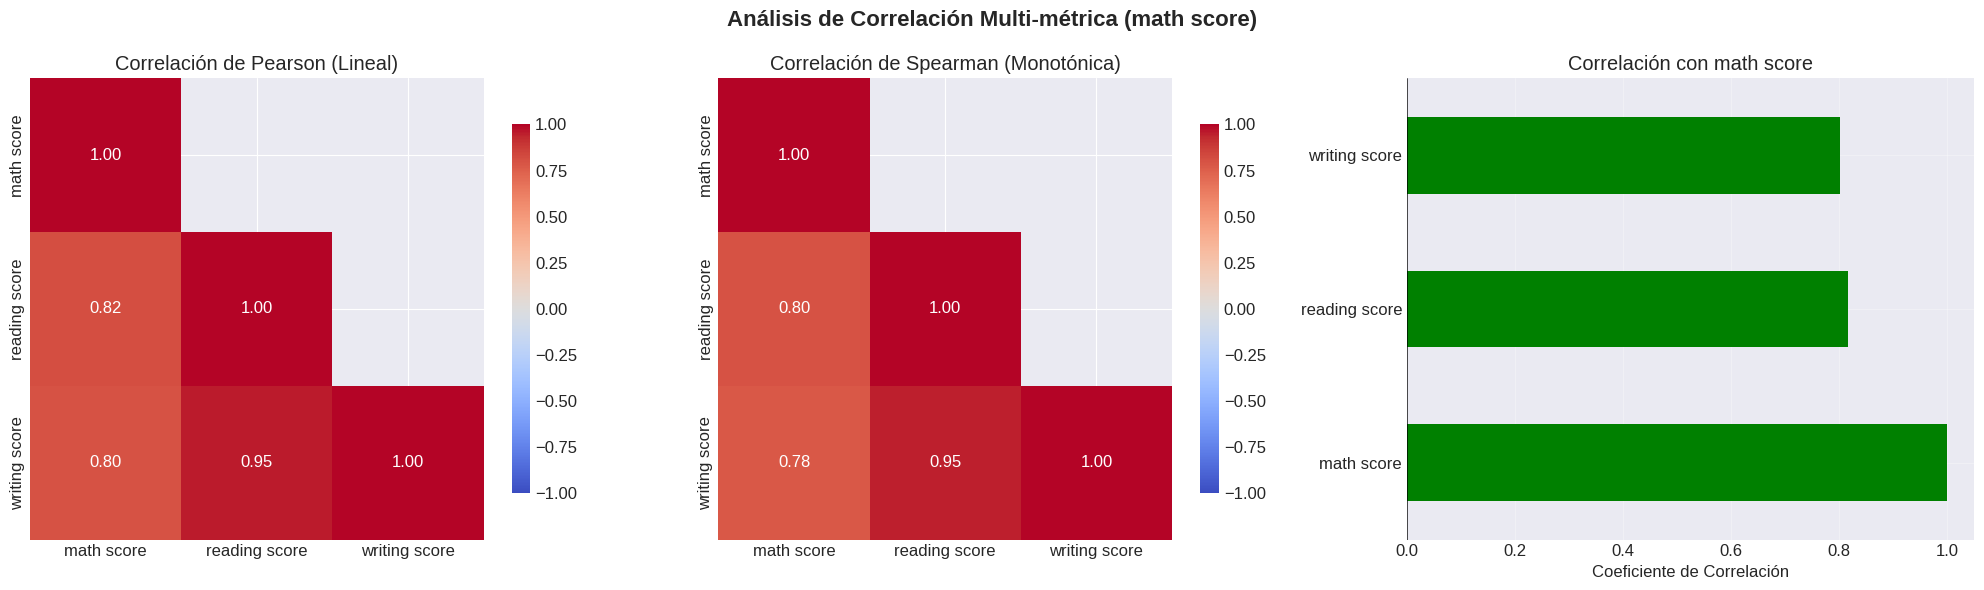

Correlaciones Significativas:
  • reading score       : +0.818 (Fuerte Positiva)
  • writing score       : +0.803 (Fuerte Positiva)

>>> Análisis de correlación usando 'reading score' como variable objetivo



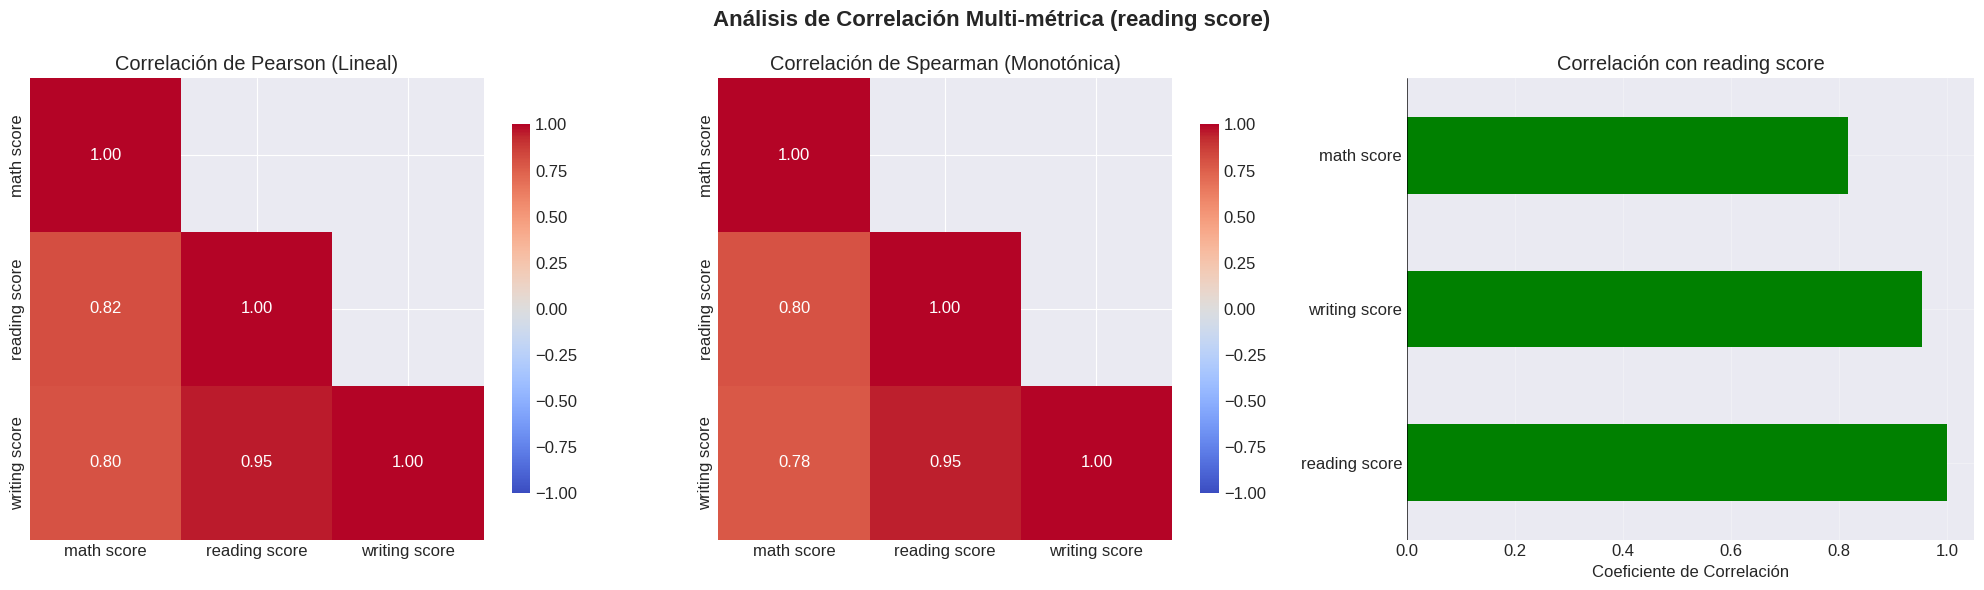

Correlaciones Significativas:
  • writing score       : +0.955 (Fuerte Positiva)
  • math score          : +0.818 (Fuerte Positiva)

>>> Análisis de correlación usando 'writing score' como variable objetivo



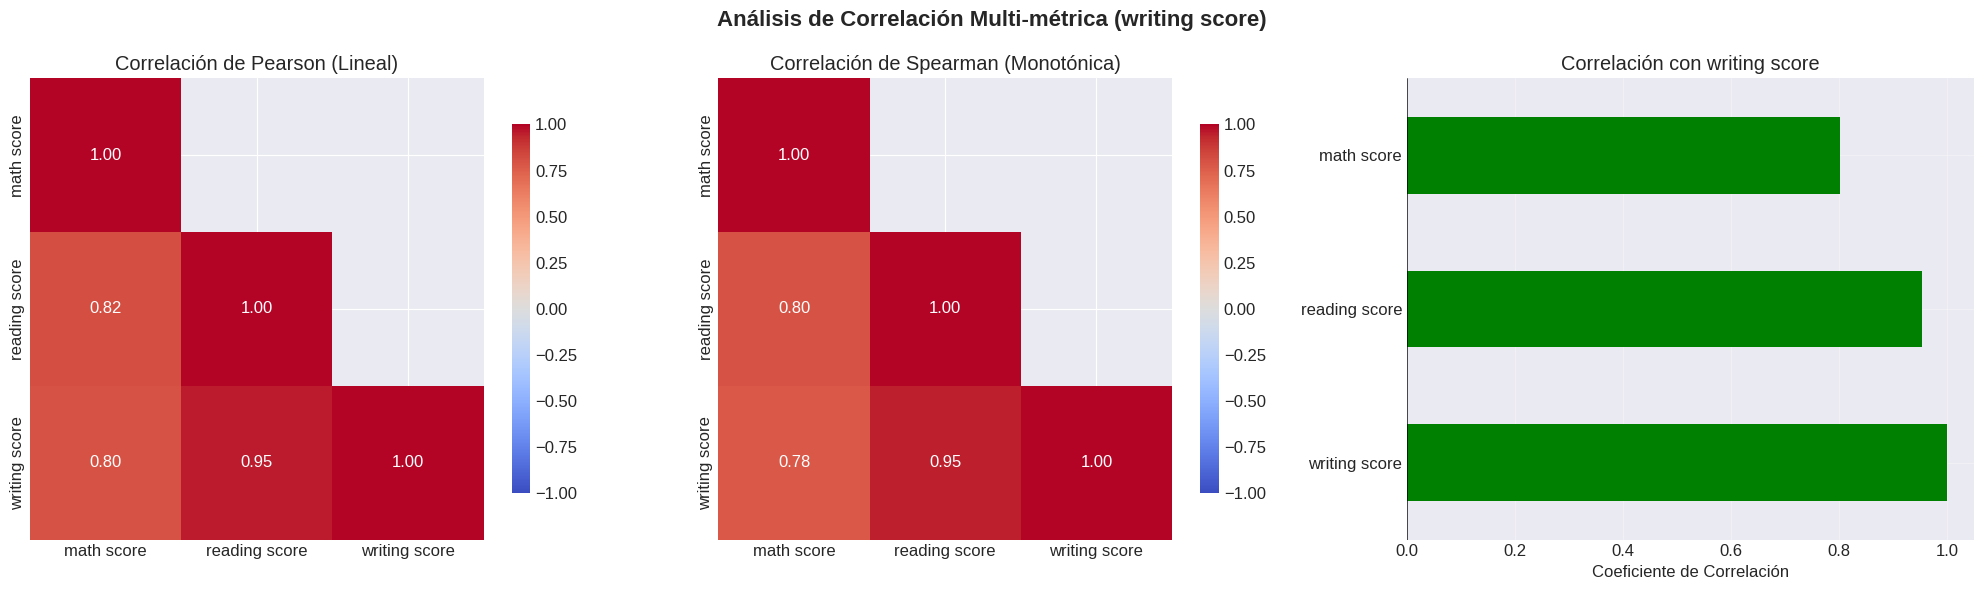

Correlaciones Significativas:
  • reading score       : +0.955 (Fuerte Positiva)
  • math score          : +0.803 (Fuerte Positiva)


In [ ]:
def correlation_analysis_students(df):
    """Análisis de correlación con múltiples métricas para cada nota"""

    numeric_cols = df.select_dtypes(include=[np.number]).columns

    for target_col in numeric_cols:
        print(f"\n{'='*70}")
        print(f">>> Análisis de correlación usando '{target_col}' como variable objetivo")
        print(f"{'='*70}\n")

        fig, axes = plt.subplots(1, 3, figsize=(20, 6))

        # 1. Correlación de Pearson
        corr_pearson = df[numeric_cols].corr(method='pearson')
        mask = np.triu(np.ones_like(corr_pearson), k=1)
        sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.2f',
                   cmap='coolwarm', center=0, ax=axes[0],
                   vmin=-1, vmax=1, cbar_kws={"shrink": 0.8})
        axes[0].set_title('Correlación de Pearson (Lineal)')

        # 2. Correlación de Spearman
        corr_spearman = df[numeric_cols].corr(method='spearman')
        sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.2f',
                   cmap='coolwarm', center=0, ax=axes[1],
                   vmin=-1, vmax=1, cbar_kws={"shrink": 0.8})
        axes[1].set_title('Correlación de Spearman (Monotónica)')

        # 3. Correlación con variable objetivo
        target_corr = df[numeric_cols].corr()[target_col].sort_values(ascending=False)
        colors = ['green' if x > 0 else 'red' for x in target_corr.values]
        target_corr.plot(kind='barh', ax=axes[2], color=colors)
        axes[2].set_title(f'Correlación con {target_col}')
        axes[2].set_xlabel('Coeficiente de Correlación')
        axes[2].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        axes[2].grid(True, alpha=0.3)

        plt.suptitle(f'Análisis de Correlación Multi-métrica ({target_col})',
                    fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # Tabla de correlaciones importantes
        print("Correlaciones Significativas:")
        print("=" * 50)
        significant_corr = target_corr[abs(target_corr) > 0.1].drop(target_col)
        for var, corr in significant_corr.items():
            strength = "Fuerte" if abs(corr) > 0.5 else "Moderada" if abs(corr) > 0.3 else "Débil"
            direction = "Positiva" if corr > 0 else "Negativa"
            print(f"  • {var:20s}: {corr:+.3f} ({strength} {direction})")


# Ejecutar sobre el dataset
correlation_analysis_students(performance)


La conclusión principal que se puede sacar de esas matrices de correlación es que **las tres variables (`math score`, `reading score` y `writing score`) están fuertemente correlacionadas entre sí**:  

1. **Correlación fuerte y positiva en todos los casos**  
   - Entre `math score` y `reading score`: ~0.82  
   - Entre `math score` y `writing score`: ~0.80  
   - Entre `reading score` y `writing score`: ~0.95 (la más alta de todas).  

   Esto significa que cuando un estudiante obtiene un puntaje alto en una de las áreas, tiende a obtenerlo también en las otras.

2. **Redundancia de información**  
   Dado que las tres variables están muy correlacionadas, existe mucha **colinealidad**. Esto implica que usar las tres como predictores en un modelo puede ser redundante. En la práctica, bastaría con una o dos de ellas, ya que aportan casi la misma información.

3. **Intercambiabilidad como variable objetivo**  
   Dado que cualquiera de las tres tiene correlaciones similares con las demás, se puede elegir `math score`, `reading score` o `writing score` como variable objetivo, y el modelo probablemente tendrá un desempeño similar al predecir una u otra.

4. **Interpretación educativa**  
   Estas correlaciones tan fuertes indican que las competencias en matemáticas, lectura y escritura no son aisladas: un buen desempeño en una suele reflejar un buen desempeño en las demás. Es decir, probablemente haya un **factor académico común** que influye en los tres puntajes.

---

**En resumen:**  
- Las tres variables están muy relacionadas.  
- `reading score` y `writing score` son prácticamente intercambiables (correlación ~0.95).  
- Se puede usar cualquiera de las tres como target, pero para evitar redundancia, conviene no usarlas todas a la vez como features.

# Detección de anomalías y outliers

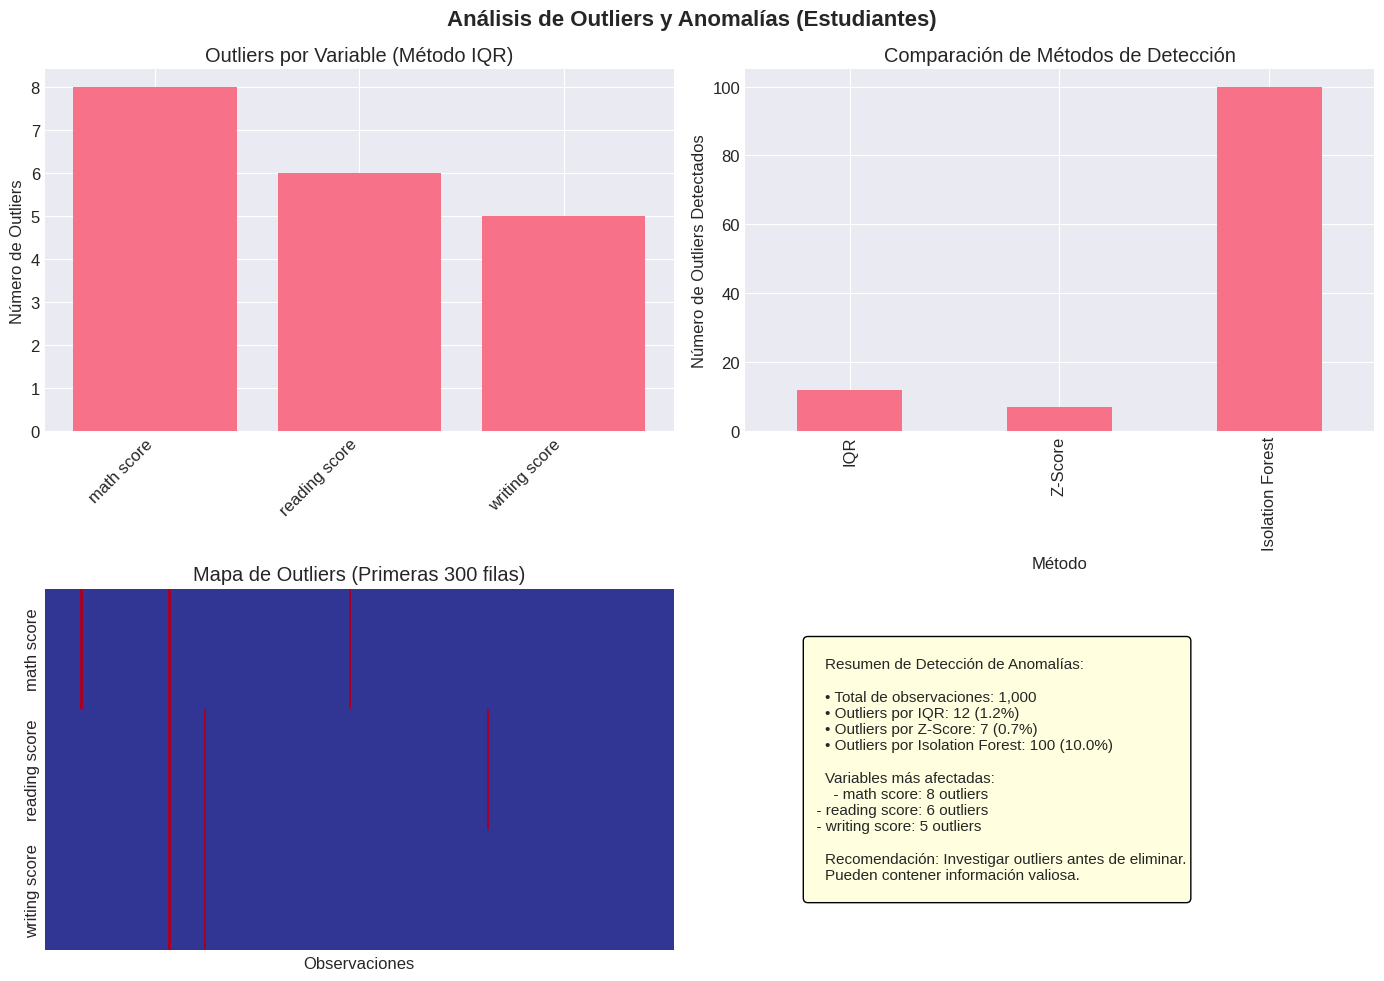

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from scipy import stats

def detect_outliers_students(df):
    """Detección de outliers en dataset de estudiantes con múltiples métodos"""

    numeric_df = df.select_dtypes(include=[np.number])

    # Método 1: IQR
    outliers_iqr = pd.DataFrame()
    for col in numeric_df.columns:
        Q1 = numeric_df[col].quantile(0.25)
        Q3 = numeric_df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((numeric_df[col] < Q1 - 1.5 * IQR) |
                   (numeric_df[col] > Q3 + 1.5 * IQR))
        outliers_iqr[col] = outliers

    # Método 2: Z-Score
    z_scores = np.abs(stats.zscore(numeric_df.fillna(numeric_df.median())))
    outliers_zscore = (z_scores > 3)

    # Método 3: Isolation Forest
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(numeric_df.fillna(numeric_df.median()))
    iso_forest = IsolationForest(contamination=0.1, random_state=42)
    outliers_iso = iso_forest.fit_predict(scaled_data) == -1

    # Visualización
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Outliers por columna (IQR)
    ax1 = axes[0, 0]
    outlier_counts = outliers_iqr.sum()
    ax1.bar(range(len(outlier_counts)), outlier_counts.values)
    ax1.set_xticks(range(len(outlier_counts)))
    ax1.set_xticklabels(outlier_counts.index, rotation=45, ha='right')
    ax1.set_title('Outliers por Variable (Método IQR)')
    ax1.set_ylabel('Número de Outliers')

    # Plot 2: Distribución de outliers por método
    ax2 = axes[0, 1]
    methods_comparison = pd.DataFrame({
        'IQR': outliers_iqr.any(axis=1).sum(),
        'Z-Score': outliers_zscore.any(axis=1).sum(),
        'Isolation Forest': outliers_iso.sum()
    }, index=['Outliers'])
    methods_comparison.T.plot(kind='bar', ax=ax2, legend=False)
    ax2.set_title('Comparación de Métodos de Detección')
    ax2.set_ylabel('Número de Outliers Detectados')
    ax2.set_xlabel('Método')

    # Plot 3: Heatmap de outliers
    ax3 = axes[1, 0]
    n_rows = 300
    sample_outliers = outliers_iqr.head(n_rows)
    sns.heatmap(sample_outliers.T, cmap='RdYlBu_r', cbar=False, ax=ax3,
               yticklabels=True, xticklabels=False)
    ax3.set_title(f'Mapa de Outliers (Primeras {n_rows} filas)')
    ax3.set_xlabel('Observaciones')

    # Plot 4: Resumen estadístico
    ax4 = axes[1, 1]
    ax4.axis('off')
    summary_text = f"""
    Resumen de Detección de Anomalías:

    • Total de observaciones: {len(df):,}
    • Outliers por IQR: {outliers_iqr.any(axis=1).sum():,} ({outliers_iqr.any(axis=1).sum()/len(df)*100:.1f}%)
    • Outliers por Z-Score: {outliers_zscore.any(axis=1).sum():,} ({outliers_zscore.any(axis=1).sum()/len(df)*100:.1f}%)
    • Outliers por Isolation Forest: {outliers_iso.sum():,} ({outliers_iso.sum()/len(df)*100:.1f}%)

    Variables más afectadas:
    {chr(10).join([f'  - {col}: {count:,} outliers'
                   for col, count in outlier_counts.nlargest(3).items()])}

    Recomendación: Investigar outliers antes de eliminar.
    Pueden contener información valiosa.
    """
    ax4.text(0.1, 0.5, summary_text, transform=ax4.transAxes,
            fontsize=11, verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow'))

    plt.suptitle('Análisis de Outliers y Anomalías (Estudiantes)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return outliers_iqr, outliers_zscore, outliers_iso

# Ejecutar con tu dataset de estudiantes
outliers_iqr, outliers_zscore, outliers_iso = detect_outliers_students(performance)


In [ ]:
def print_outliers_info(df, outliers_iqr, outliers_zscore, outliers_iso):
    """Imprime información detallada de los outliers detectados"""

    print("\n========== Resumen General ==========")
    print(f"Total de observaciones: {len(df)}")
    print(f"Outliers por IQR: {outliers_iqr.any(axis=1).sum()} ({outliers_iqr.any(axis=1).mean()*100:.1f}%)")
    print(f"Outliers por Z-Score: {outliers_zscore.any(axis=1).sum()} ({outliers_zscore.any(axis=1).mean()*100:.1f}%)")
    print(f"Outliers por Isolation Forest: {outliers_iso.sum()} ({outliers_iso.mean()*100:.1f}%)")

    # Identificar índices afectados
    iqr_idx = df[outliers_iqr.any(axis=1)].index
    z_idx = df[outliers_zscore.any(axis=1)].index
    iso_idx = df[outliers_iso].index

    print("\n========== Ejemplos de Outliers ==========")
    print("\n--- Método IQR ---")
    print(df.loc[iqr_idx].head(5))

    print("\n--- Método Z-Score ---")
    print(df.loc[z_idx].head(5))

    print("\n--- Método Isolation Forest ---")
    print(df.loc[iso_idx].head(5))

    # Intersección de métodos
    combined_outliers = set(iqr_idx) & set(z_idx) & set(iso_idx)
    print("\n========== Intersección ==========")
    print(f"Observaciones detectadas como outliers por los 3 métodos: {len(combined_outliers)}")
    if combined_outliers:
        print(df.loc[list(combined_outliers)].head())

print_outliers_info(performance, outliers_iqr, outliers_zscore, outliers_iso)



========== Resumen General ==========
Total de observaciones: 1000
Outliers por IQR: 12 (1.2%)
Outliers por Z-Score: 7 (0.7%)
Outliers por Isolation Forest: 100 (10.0%)

========== Ejemplos de Outliers ==========

--- Método IQR ---
     gender race/ethnicity parental level of education         lunch  \
17   female        group B            some high school  free/reduced   
59   female        group C            some high school  free/reduced   
76     male        group E            some high school      standard   
145  female        group C                some college  free/reduced   
211    male        group C                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
17                     none          18             32             28  
59                     none           0             17             10  
76                     none          30             26             22  
145                    none          22      